# Predicting League of Legends (LoL) Match Outcomes Using 10-Minute Data

## 1. Introduction & Background

### The Objective of the Game
League of Legends คือเกมวางกลยุทธ์แบบทีม 5 ต่อ 5 เป้าหมายหลักของเกมคือการ **ทำลายโครงสร้างหลักของฐานฝ่ายตรงข้าม ที่เรียกว่า Nexus** อย่างไรก็ตาม ผู้เล่นไม่สามารถเดินตรงไปยังฐานศัตรูได้ทันที แต่ละเกมเริ่มต้นที่เลเวล 1 โดยไม่มีไอเทมใดๆ เพื่อไปถึง Nexus ของฝ่ายตรงข้าม ทีมต้องสะสมพลังและควบคุมแผนที่อย่างเป็นระบบผ่านทรัพยากรหลัก 2 ประเภท:
* **ประสบการณ์ (XP):** เพิ่ม Stats พื้นฐานและปลดล็อกทักษะของผู้เล่น
* **ทอง (Gold):** สกุลเงินหลักสำหรับซื้อไอเทมที่เพิ่มพลังของผู้เล่นอย่างมหาศาล

ผู้เล่นได้รับทรัพยากรเหล่านี้จากการกระทำต่างๆ บนแผนที่ เช่น การสังหาร Minion ที่ควบคุมโดย AI (CS หรือ Creep Score), การทำลาย Turret, การ Secure สัตว์ประหลาดกลางแผนที่ (เช่น Dragon หรือ Rift Herald) และการกำจัดผู้เล่นฝ่ายตรงข้าม

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('data/t2_transformed/aggregated.csv')
df_standard = df.copy()

## Section 1: The Economy (Gold & CS)

ใน League of Legends ทุกอย่างขับเคลื่อนด้วยทรัพยากร ก่อนที่จะวิเคราะห์ทักษะผู้เล่นหรือการควบคุม Objective เราต้องสร้างความเข้าใจพื้นฐานด้านเศรษฐกิจของเกมก่อน

### 1.1 Team Gold — Win Probability by Gold Difference
ทองใช้ซื้อไอเทม และไอเทมทวีคูณพลัง ขั้นแรกของเราคือการทำความเข้าใจว่าต้องมีความได้เปรียบด้านทองมากแค่ไหนที่ 10 นาที จึงจะสามารถทำนายการชนะได้อย่างน่าเชื่อถือ

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\38104044.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_prob_df = df_standard.groupby('gold_diff_bin')['BlueWin'].mean().reset_index()


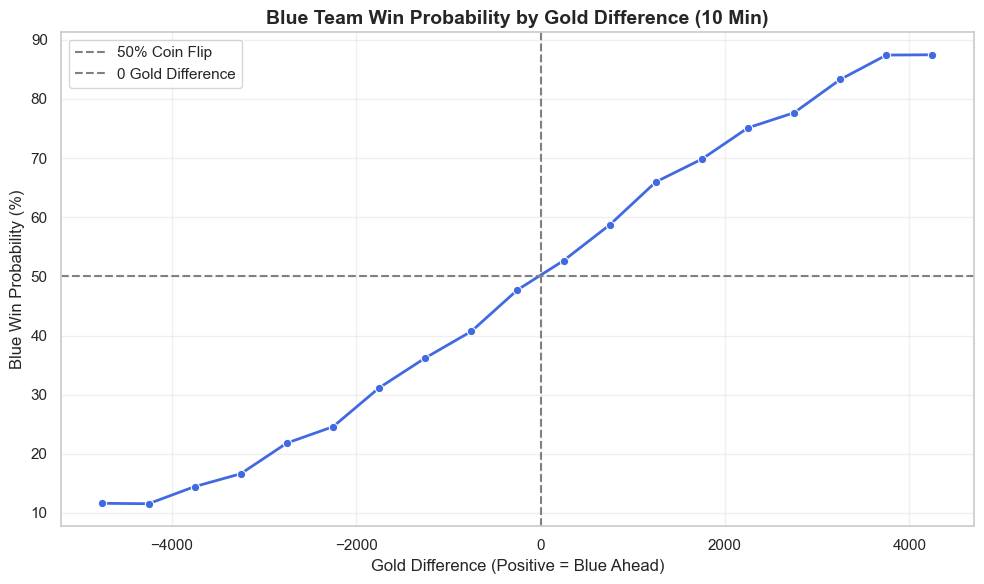

In [4]:
bins = np.arange(-5000, 5000, 500)
labels = [f"{b/1000}k to {(b+500)/1000}k" for b in bins[:-1]]
df_standard['gold_diff_bin'] = pd.cut(df_standard['Diff_TotalGold'], bins=bins, labels=labels)
win_prob_df = df_standard.groupby('gold_diff_bin')['BlueWin'].mean().reset_index()
win_prob_df['BlueWin'] = win_prob_df['BlueWin'] * 100
win_prob_df['gold_diff_midpoint'] = bins[:-1] + 250
plt.figure(figsize=(10, 6))
sns.lineplot(x='gold_diff_midpoint', y='BlueWin', data=win_prob_df, marker='o', color='royalblue', linewidth=2)
plt.axhline(50, color='gray', linestyle='--', label='50% Coin Flip')
plt.axvline(0, color='gray', linestyle='--', label='0 Gold Difference')
plt.title('Blue Team Win Probability by Gold Difference (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Gold Difference (Positive = Blue Ahead)', fontsize=12)
plt.ylabel('Blue Win Probability (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ที่ Gold Difference เท่ากับ 0 เกมจะมีสภาพไม่ต่างอะไรกับการโยนเหรียญหัวก้อย (โอกาสชนะ 50/50)
แต่เมื่อใดที่ทีมสามารถทำเงินทิ้งห่างได้ประมาณ 1,500–2,000 Gold โอกาสชนะจะพุ่งสูงขึ้นถง 70% ทันที จุดนี้ชี้ให้เห็นถึง **จุด Snowball** อย่างชัดเจน มันคือจุดที่ความได้เปรียบเพียงเล็กน้อย ถูกทวีคูณอย่างรวดเร็วผ่านไอเทมที่เหนือกว่า การคุม Objective ที่ดีกว่า และแรงกดดันบนแผนที่ที่เพิ่มสูงขึ้น

แต่เมื่อเงินห่างกันมากกว่า 4,000 Gold ขึ้นไป กราฟจะเริ่มแบนราบและคงที่อยู่แถวๆ 88–90% ซึ่งแสดงให้เห็นถึงภาวะ Diminishing Returns (การลดน้อยถอยลงของผลตอบแทน) ณ จุดนั้น ผลแพ้ชนะแทบจะถูกตัดสินไปเรียบร้อยแล้ว การหาเงินเพิ่มหลังจากนี้จึงแทบไม่ได้ช่วยเพิ่มโอกาสชนะ

### 1.2 Team Gold — Separation Power (KDE Distribution)
ต่อมาเราจะตรวจสอบว่าผลต่างทองสามารถแยกแยะเกมที่ชนะออกจากเกมที่แพ้ได้ดีแค่ไหน โดยใช้การกระจายความหนาแน่น

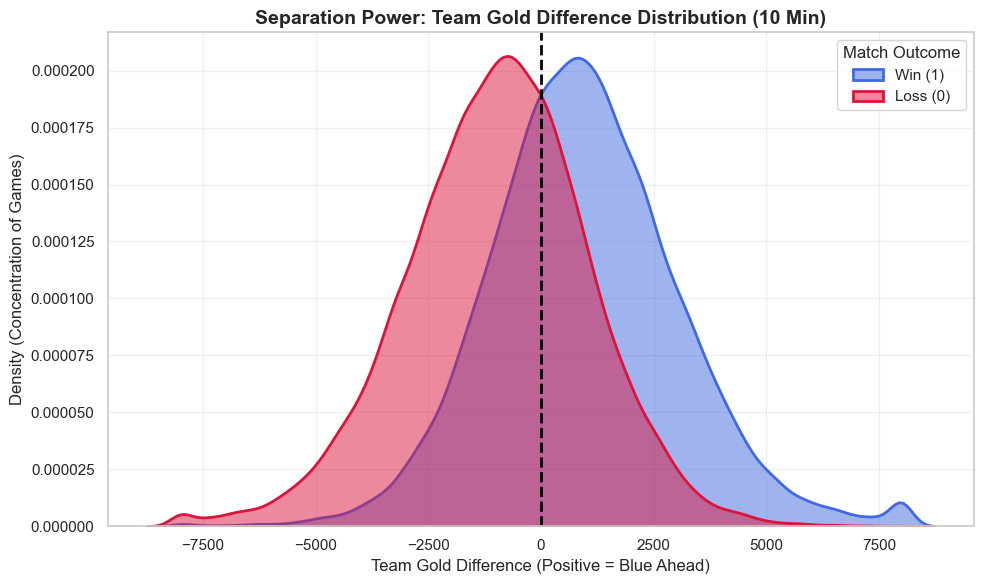

In [5]:
df_standard['GoldDiff_Capped'] = df_standard['Diff_TotalGold'].clip(-8000, 8000)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_standard,
    x='GoldDiff_Capped',
    hue='BlueWin',
    fill=True,
    common_norm=False,
    palette={1: 'royalblue', 0: 'crimson', '1': 'royalblue', '0': 'crimson'},
    alpha=0.5,
    linewidth=2
)

plt.title('Separation Power: Team Gold Difference Distribution (10 Min)', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='0 Gold Diff (Dead Even)')
plt.xlabel('Team Gold Difference (Positive = Blue Ahead)', fontsize=12)
plt.ylabel('Density (Concentration of Games)', fontsize=12)
plt.legend(title='Match Outcome', labels=['Win (1)', 'Loss (0)'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

กราฟความหนาแน่น นี้แสดงให้เห็นถึงอำนาจในการจำแนกผลการแข่งขันของผลต่างทอง ณ นาทีที่ 10 โดยการกระจายตัวสีน้ำเงินที่แทนเกมที่ชนะจะถูกเลื่อนไปทางขวา ส่วนการกระจายตัวสีแดงที่แทนเกมที่แพ้จะถูกเลื่อนไปทางซ้าย

สิ่งนี้หมายความว่าโดยปกติแล้ว ทีมที่ชนะมักจะมีทองนำในช่วงนาทีที่ 10 ในขณะที่ทีมที่แพ้มักจะมีทองตามหลัง การทับซ้อนกันบริเวณค่าศูนย์แสดงให้เห็นว่าเกมที่สูสีกันนั้นยังยากที่จะคาดเดาผล แต่เมื่อผลต่างทองเริ่มห่างออกไป การกระจายตัวทั้งสองจะแยกออกจากกันอย่างชัดเจนมากขึ้น

การกระจายตัวของเกมที่ชนะจะค่อนไปทางขวา ในขณะที่การกระจายตัวของเกมที่แพ้จะค่อนไปทางซ้าย ซึ่งหมายความว่าการชนะของทีมสีน้ำเงินมักเกิดขึ้นเมื่อมีผลต่างทองเป็นบวก (นำอยู่) และการแพ้มักเกิดขึ้นเมื่อมีผลต่างทองเป็นลบ (ตามหลัง)

จุดที่สำคัญที่สุดคือ การแยกออกจากกันของเส้นโค้งทั้งสอง เส้นสีน้ำเงินมีจุดสูงสุดอยู่ในฝั่งบวก ขณะที่เส้นสีแดงมีจุดสูงสุดอยู่ในฝั่งลบ สิ่งนี้แสดงให้เห็นว่าผลต่างของทอง ณ นาทีที่ 10 สามารถแยกระหว่างการชนะและการแพ้ที่สูงมาก

อย่างไรก็ตาม เส้นโค้งทั้งสองยังคงมีการ ทับซ้อนกันอยู่ในช่วงตรงกลาง ซึ่งหมายความว่าผลต่างทองไม่ใช่ตัวพยากรณ์ที่สมบูรณ์แบบ 100% เพราะบางทีมยังสามารถพลิกกลับมาชนะได้แม้จะมีทองตามหลัง และบางทีมก็อาจแพ้ได้แม้จะมีทองนำอยู่ โดยเฉพาะในช่วงที่ผลต่างทองใกล้เคียง 0 ผลการแข่งขันจะยังมีความไม่แน่นอนสูง

### 1.3 Lane Gold — Raw Correlation (Blue Team Only)
แม้ทองรวมของทีมจะเป็นตัวบ่งชี้ที่ดีที่สุด แต่ทีม LoL ประกอบด้วยผู้เล่น 5 คน คำถามต่อมาคือ **ใครในทีมที่ถือทองไว้มีความสำคัญต่อชัยชนะมากกว่ากัน?**

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1195625180.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


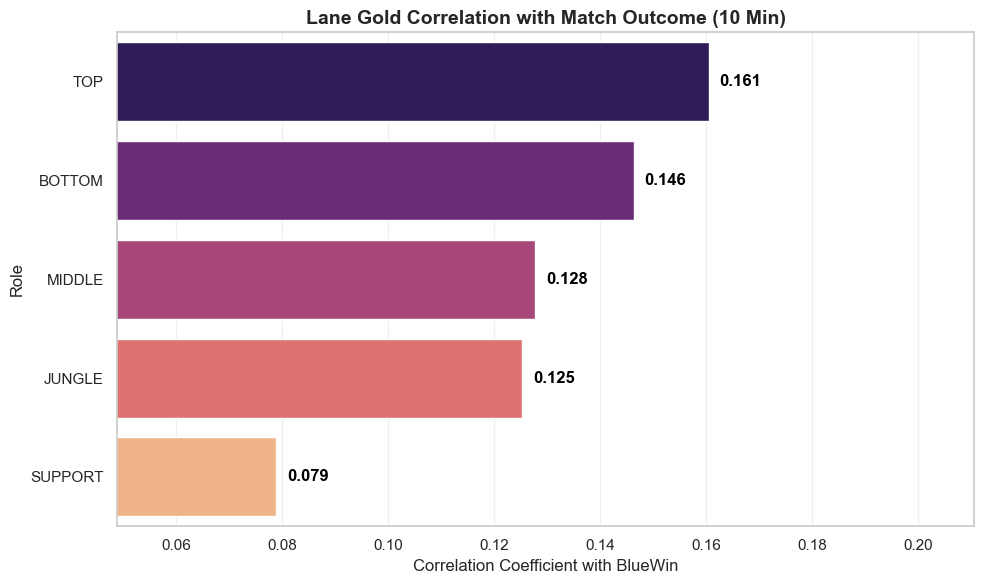

In [48]:
subset = df_standard[['MatchFk', 'BlueWin'] +
                     [f'Lane_P{i}' for i in range(1,6)] +
                     [f'TotalGold_P{i}' for i in range(1,6)]].copy()

melted = pd.wide_to_long(
    subset.reset_index(),
    stubnames=['Lane_P', 'TotalGold_P'],
    i='MatchFk',
    j='PlayerNum'
)

lane_gold = melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['TotalGold_P'].mean().reset_index()
pivoted = lane_gold.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='TotalGold_P').reset_index()

lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
pivoted = pivoted.dropna(subset=lanes_to_keep)

correlations = pivoted[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin')
correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

for i, v in enumerate(correlations.values):
    offset = 0.002 if v >= 0 else -0.002
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f"{v:.3f}", color='black', va='center', fontweight='bold', ha=ha)

plt.title('Lane Gold Correlation with Match Outcome (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.xlim(min(correlations.values) - 0.03, max(correlations.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

แผนภูมินี้แสดงให้เห็นความสัมพันธ์ระหว่างทองในแต่ละตำแหน่ง ณ นาทีที่ 10 กับผลการแข่งขัน โดยเลนบนมีความสัมพันธ์กับการชนะสูงที่สุด ตามมาด้วยเลนล่าง สิ่งนี้ชี้ให้เห็นว่าความได้เปรียบเรื่องทองในช่วงต้นเกมในเลนบนและเลนล่างนั้นเชื่อมโยงกับการคว้าชัยชนะมากที่สุด เลนกลางและป่าก็แสดงความสัมพันธ์เชิงบวกเช่นกันแต่จะน้อยกว่าเล็กน้อย

ส่วนซัพพอร์ตมีความสัมพันธ์ต่ำสุดเพราะผลกระทบของตำแหน่งนี้ต่อเกมไม่ได้วัดจากจำนวนทองเป็นหลัก โดยรวมแล้ว กราฟนี้บ่งบอกว่าความได้เปรียบเรื่องทองในแต่ละตำแหน่งมีความสำคัญต่อรูปเกม แต่ระดับความสำคัญนั้นจะแตกต่างกันไปตามบทบาทหน้าที่ของแต่ละตำแหน่ง

แต่ปัญหาของกราฟนี้คือ การที่เลน TOP ของเราหาเงินได้ 4,000 Gold ไม่ได้แปลว่าเราได้เปรียบเสมอไป เพราะ TOP ฝั่งตรงข้ามก็อาจจะฟาร์มได้ 4,000 Gold เท่ากัน

### 1.3 Lane Gold — Direct Matchup Difference (Blue vs Red)
ตัวเลขทองดิบๆ นั้นทำให้เข้าใจผิดได้ คำถามที่แท้จริงคือ ผู้เล่นของเราสามารถ **สร้างรายได้มากกว่าคู่แข่งตรงข้ามในเลนเดียวกัน** ได้หรือไม่?

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1700086858.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


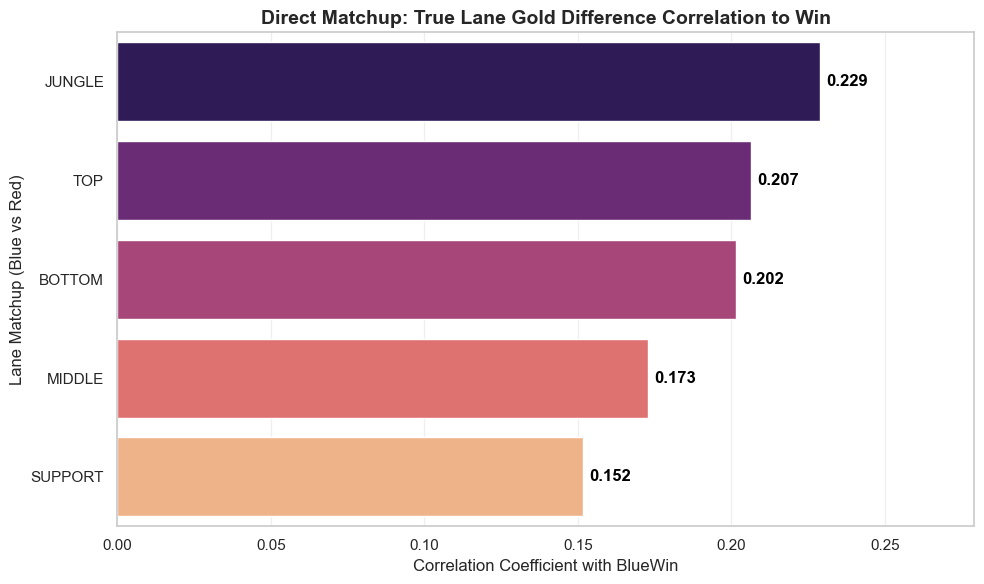

In [47]:
blue_subset = df_standard[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'TotalGold_P{i}' for i in range(1,6)]].copy()
blue_melted = pd.wide_to_long(blue_subset.reset_index(), stubnames=['Lane_P', 'TotalGold_P'], i='MatchFk', j='PlayerNum')
blue_lanes = blue_melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['TotalGold_P'].mean().reset_index()
blue_lanes.rename(columns={'TotalGold_P': 'BlueGold'}, inplace=True)

red_subset = df_standard[['MatchFk'] + [f'Lane_P{i}' for i in range(6,11)] + [f'TotalGold_P{i}' for i in range(6,11)]].copy()
rename_dict = {f'Lane_P{i}': f'Lane_P{i-5}' for i in range(6, 11)}
rename_dict.update({f'TotalGold_P{i}': f'TotalGold_P{i-5}' for i in range(6, 11)})
red_subset = red_subset.rename(columns=rename_dict)

red_melted = pd.wide_to_long(red_subset.reset_index(), stubnames=['Lane_P', 'TotalGold_P'], i='MatchFk', j='PlayerNum')
red_lanes = red_melted.groupby(['MatchFk', 'Lane_P'])['TotalGold_P'].mean().reset_index()
red_lanes.rename(columns={'TotalGold_P': 'RedGold'}, inplace=True)

matchups = pd.merge(blue_lanes, red_lanes, on=['MatchFk', 'Lane_P'], how='inner')
matchups['Lane_Gold_Diff'] = matchups['BlueGold'] - matchups['RedGold']

diff_pivot = matchups.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='Lane_Gold_Diff').reset_index()
lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
correlations = diff_pivot[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

for i, v in enumerate(correlations.values):
    ax.text(v + 0.002, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

plt.title('Direct Matchup: True Lane Gold Difference Correlation to Win', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Lane Matchup (Blue vs Red)', fontsize=12)
plt.xlim(0, max(correlations.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

เมื่อเปรียบเทียบกราฟความสัมพันธ์ของทองทั้งสองรูปแบบ จะเห็นได้ว่ากราฟ Direct matchup gold difference ให้ภาพรวมของอิทธิพลในแต่ละตำแหน่งที่ชัดเจนกว่า ในกราฟ Lane Gold Correlation with Match Outcome ตำแหน่งเลนบนมีค่าความสัมพันธ์สูงสุดเนื่องจากพิจารณาเพียงทองรายบุคคลของฝั่งสีน้ำเงินเท่านั้น แต่เมื่อเราเปรียบเทียบแต่ละตำแหน่งกับคู่แข่งโดยตรง ตำแหน่งป่ากลับกลายเป็นตำแหน่งที่สำคัญที่สุด โดยมีค่าความสัมพันธ์สูงถึง 0.229

### 1.4 Team CS — Farming Fundamentals (Box Plot)
CS (Creep Score) คือตัวชี้วัดการฟาร์มหลักของเกม ทีมที่ฟาร์ม Minion ได้มากกว่าจะสะสมทองแบบ Passive ได้มากขึ้นตลอดเกม

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\3647305002.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


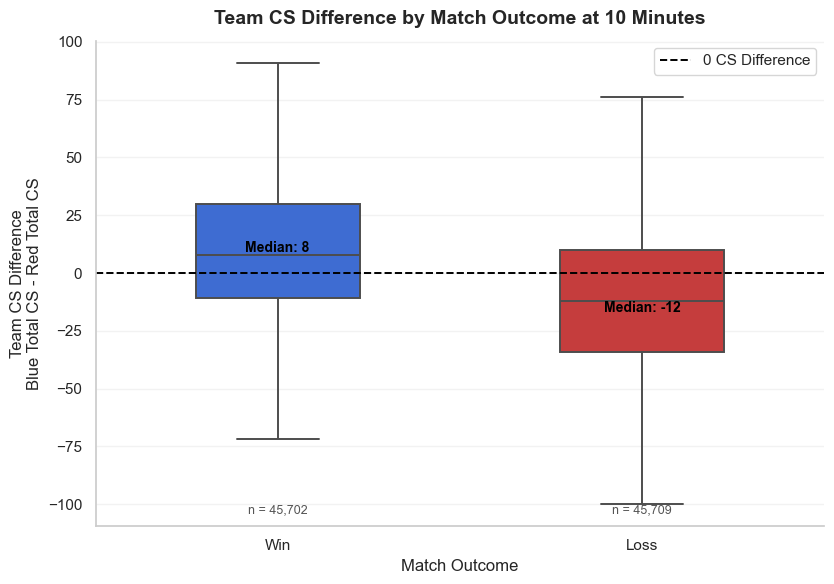

In [61]:
blue_cs_cols = [f"MinionsKilled_P{i}" for i in range(1, 6)]
red_cs_cols = [f"MinionsKilled_P{i}" for i in range(6, 11)]
df_standard["Blue_Total_CS"] = df_standard[blue_cs_cols].sum(axis=1)
df_standard["Red_Total_CS"] = df_standard[red_cs_cols].sum(axis=1)
df_standard["Team_CS_Diff"] = df_standard["Blue_Total_CS"] - df_standard["Red_Total_CS"]
df_standard["Outcome"] = df_standard["BlueWin"].map({1: "Win", 0: "Loss"})
plot_df = df_standard[["Outcome", "Team_CS_Diff"]].dropna().copy()
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8.5, 6))
palette = {
    "Win": "#2563eb",
    "Loss": "#dc2626"
}
sns.boxplot(
    data=plot_df,
    x="Outcome",
    y="Team_CS_Diff",
    order=["Win", "Loss"],
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=1.4,
    ax=ax
)
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="0 CS Difference"
)
medians = plot_df.groupby("Outcome")["Team_CS_Diff"].median()
for i, outcome in enumerate(["Win", "Loss"]):
    median_value = medians[outcome]
    ax.text(
        i,
        median_value,
        f"Median: {median_value:,.0f}",
        ha="center",
        va="bottom" if median_value >= 0 else "top",
        fontsize=10,
        fontweight="bold",
        color="black"
    )
counts = plot_df["Outcome"].value_counts()
y_min, y_max = ax.get_ylim()
for i, outcome in enumerate(["Win", "Loss"]):
    ax.text(
        i,
        y_min + (y_max - y_min) * 0.02,
        f"n = {counts[outcome]:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555555"
    )
ax.set_title(
    "Team CS Difference by Match Outcome at 10 Minutes",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Match Outcome", fontsize=12)
ax.set_ylabel("Team CS Difference\nBlue Total CS - Red Total CS", fontsize=12)
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

กราฟแสดงให้เห็นว่าทีมที่ชนะมักจะมีความได้เปรียบเรื่อง CS (Creep Score) ณ นาทีที่ 10 โดยค่ามัธยฐาน (Median) ของผลต่าง CS สำหรับกลุ่มที่ชนะคือ +8 หมายความว่าในเกมที่ชนะโดยทั่วไป ทีมสีน้ำเงินจะมี CS มากกว่าทีมสีแดงประมาณ 8 ตัว

สำหรับกลุ่มที่แพ้ ค่ามัธยฐานจะอยู่ที่ -12 หมายความว่าในเกมที่แพ้โดยทั่วไป ทีมสีน้ำเงินจะมี CS น้อยกว่าทีมสีแดงประมาณ 12 ตัว

อย่างไรก็ตาม แผนภาพกล่อง ทั้งสองชุดยังคงมีการทับซ้อนกันอยู่บ้าง ซึ่งหมายความว่าบางทีมยังสามารถชนะได้แม้จะมี CS ตามหลัง และบางทีมก็อาจแพ้ได้แม้จะมี CS นำอยู่

### 1.5 Lane CS — Raw Correlation by Role

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\3796047188.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations_cs.values, y=correlations_cs.index, palette='magma')


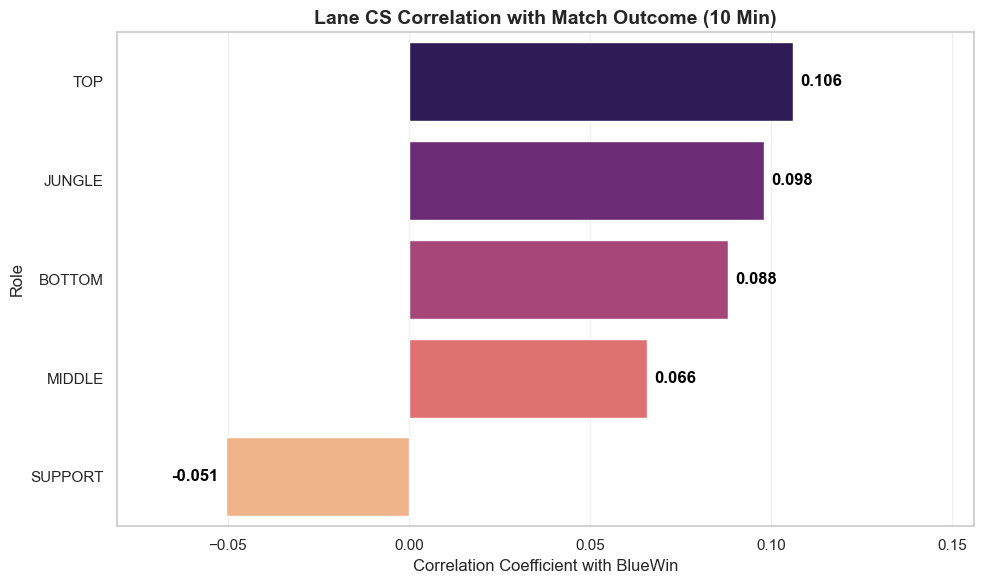

In [57]:
subset_cs = df_standard[['MatchFk', 'BlueWin'] +
                        [f'Lane_P{i}' for i in range(1,6)] +
                        [f'MinionsKilled_P{i}' for i in range(1,6)]].copy()

melted_cs = pd.wide_to_long(
    subset_cs.reset_index(),
    stubnames=['Lane_P', 'MinionsKilled_P'],
    i='MatchFk',
    j='PlayerNum'
)

lane_cs = melted_cs.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['MinionsKilled_P'].mean().reset_index()
pivoted_cs = lane_cs.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='MinionsKilled_P').reset_index()

lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
pivoted_cs = pivoted_cs.dropna(subset=lanes_to_keep)

correlations_cs = pivoted_cs[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations_cs.values, y=correlations_cs.index, palette='magma')

for i, v in enumerate(correlations_cs.values):
    offset = 0.002 if v >= 0 else -0.002
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f"{v:.3f}", color='black', va='center', fontweight='bold', ha=ha)

plt.title('Lane CS Correlation with Match Outcome (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.xlim(min(correlations_cs.values) - 0.03, max(correlations_cs.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟแท่งนี้แสดงค่าความสัมพันธ์ (Correlation) ระหว่าง ส่วนต่างของการฟาร์ม (CS Difference) ของผู้เล่นแต่ละตำแหน่งในช่วง 10 นาทีแรก กับ ผลแพ้ชนะของเกม

จะเห็นได้ว่าตำแหน่ง Top และ Jungle มีค่าความสัมพันธ์เชิงบวกที่สูงที่สุด ซึ่งหมายความว่าการชิงความได้เปรียบเรื่องการฟาร์มตั้งแต่ต้นเกมใน 2 ตำแหน่งนี้ มีความเชื่อมโยงกับโอกาสในการชนะมากที่สุด ส่วนตำแหน่ง Bottom และ Middle ก็แสดงความสัมพันธ์เชิงบวกเช่นเดียวกันครับ แต่จะมีน้ำหนักที่อ่อนกว่า

จุดที่น่าสนใจคือ Support เป็นเพียงตำแหน่งเดียวที่มีค่าความสัมพันธ์ติดลบ ซึ่งสอดคล้องกับลอจิกของเกมและสมเหตุสมผล เพราะผู้เล่นซัพพอร์ตไม่ได้มีหน้าที่หลักในการฟาร์ม

ผลลัพธ์นี้ชี้ให้เห็นว่าความได้เปรียบจากการฟาร์มในช่วงต้นเกมนั้นมีความสำคัญ แต่ผลกระทบ (Impact) ของมันจะแตกต่างกันไปในแต่ละตำแหน่ง โดยการที่ตำแหน่ง Top และ Jungle สามารถฟาร์มทิ้งห่างคู่แข่งได้


### 1.6 Lane CS — Direct Matchup Difference (Blue vs Red)

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\3248488153.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


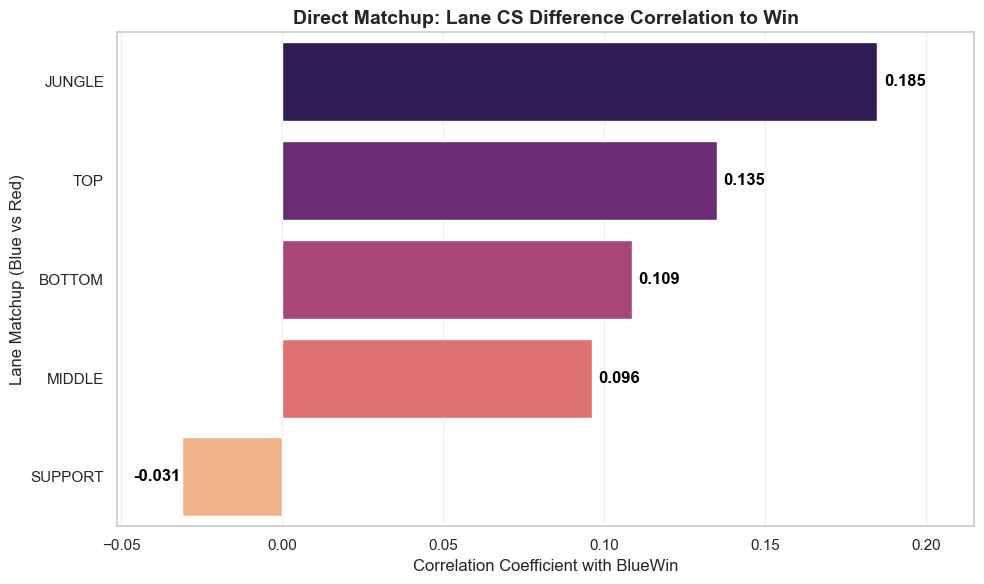

In [58]:
blue_subset = df_standard[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'MinionsKilled_P{i}' for i in range(1,6)]].copy()
blue_melted = pd.wide_to_long(blue_subset.reset_index(), stubnames=['Lane_P', 'MinionsKilled_P'], i='MatchFk', j='PlayerNum')
blue_lanes = blue_melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['MinionsKilled_P'].mean().reset_index()
blue_lanes.rename(columns={'MinionsKilled_P': 'BlueCS'}, inplace=True)

red_subset = df_standard[['MatchFk'] + [f'Lane_P{i}' for i in range(6,11)] + [f'MinionsKilled_P{i}' for i in range(6,11)]].copy()
rename_dict = {f'Lane_P{i}': f'Lane_P{i-5}' for i in range(6, 11)}
rename_dict.update({f'MinionsKilled_P{i}': f'MinionsKilled_P{i-5}' for i in range(6, 11)})
red_subset = red_subset.rename(columns=rename_dict)

red_melted = pd.wide_to_long(red_subset.reset_index(), stubnames=['Lane_P', 'MinionsKilled_P'], i='MatchFk', j='PlayerNum')
red_lanes = red_melted.groupby(['MatchFk', 'Lane_P'])['MinionsKilled_P'].mean().reset_index()
red_lanes.rename(columns={'MinionsKilled_P': 'RedCS'}, inplace=True)

matchups = pd.merge(blue_lanes, red_lanes, on=['MatchFk', 'Lane_P'], how='inner')
matchups['Lane_CS_Diff'] = matchups['BlueCS'] - matchups['RedCS']

diff_pivot = matchups.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='Lane_CS_Diff').reset_index()
lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
correlations = diff_pivot[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

for i, v in enumerate(correlations.values):
    offset = 0.002 if v > 0 else -0.015
    ax.text(v + offset, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

plt.title('Direct Matchup: Lane CS Difference Correlation to Win', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Lane Matchup (Blue vs Red)', fontsize=12)
plt.xlim(min(0, min(correlations.values) - 0.02), max(0, max(correlations.values) + 0.03))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

แผนภูมินี้แสดงความสัมพันธ์ระหว่าง ผลต่าง CS แบบตำแหน่งต่อตำแหน่ง (Direct lane CS difference) ณ นาทีที่ 10 กับผลการแข่งขัน โดยตำแหน่งป่ามีความสัมพันธ์กับการชนะสูงที่สุด ตามมาด้วยเลนบน สิ่งนี้บ่งชี้ว่าความได้เปรียบเรื่องการฟาร์มในช่วงต้นเกมจะมีความหมายมากที่สุดเมื่อเกิดขึ้นในตำแหน่งป่า

เลนบน, เลนล่าง และเลนกลาง ต่างก็แสดงความสัมพันธ์เชิงบวก ซึ่งหมายความว่าความได้เปรียบในการฟาร์มในเลนเหล่านี้ยังคงเป็นประโยชน์ต่อทีม ส่วนซัพพอร์ตเป็นตำแหน่งเดียวที่มีค่าความสัมพันธ์เป็นลบเนื่องจากไม่ใช่ตำแหน่งที่เน้นการฟาร์ม โดยรวมแล้ว กราฟนี้แสดงให้เห็นว่า ผลต่างของ CS จะมีความสำคัญมากขึ้นเมื่อวัดเป็นความได้เปรียบเทียบกับคู่แข่งโดยตรง มากกว่าการดูแค่จำนวน CS รวมเพียงอย่างเดียว

## Section 2: Combat (Kills & KDA)

เศรษฐกิจเล่าครึ่งหนึ่งของเรื่อง อีกครึ่งหนึ่งคือการต่อสู้ — ใครชนะการต่อสู้ และมีประสิทธิภาพแค่ไหน

### 2.1 Team Kills — Box Plot

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1197730086.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


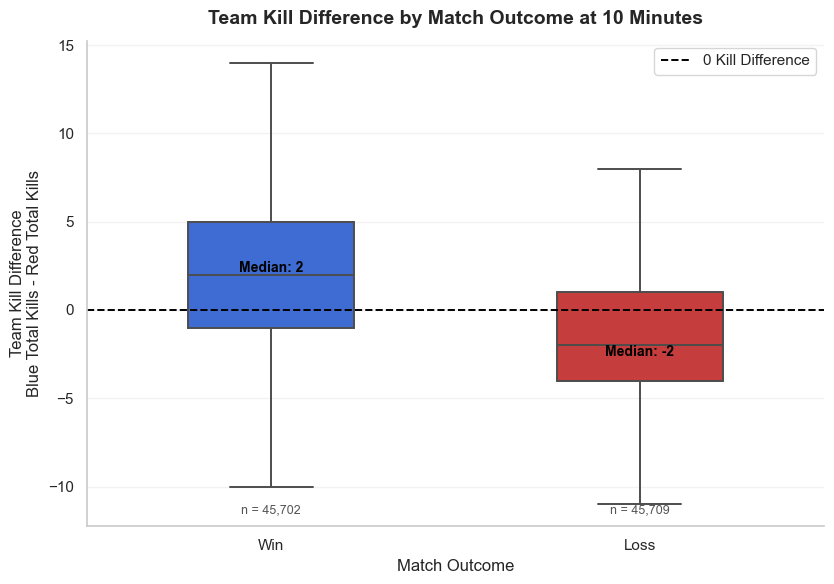

In [37]:
blue_kill_cols = [f"kills_P{i}" for i in range(1, 6)]
red_kill_cols = [f"kills_P{i}" for i in range(6, 11)]
df_standard["Blue_Total_Kills"] = df_standard[blue_kill_cols].sum(axis=1)
df_standard["Red_Total_Kills"] = df_standard[red_kill_cols].sum(axis=1)
df_standard["Team_Kill_Diff"] = df_standard["Blue_Total_Kills"] - df_standard["Red_Total_Kills"]
df_standard["Outcome"] = df_standard["BlueWin"].map({1: "Win", 0: "Loss"})
plot_df = df_standard[["Outcome", "Team_Kill_Diff"]].dropna().copy()
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8.5, 6))
palette = {
    "Win": "#2563eb",
    "Loss": "#dc2626"
}
sns.boxplot(
    data=plot_df,
    x="Outcome",
    y="Team_Kill_Diff",
    order=["Win", "Loss"],
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=1.4,
    ax=ax
)
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="0 Kill Difference"
)
medians = plot_df.groupby("Outcome")["Team_Kill_Diff"].median()
for i, outcome in enumerate(["Win", "Loss"]):
    median_value = medians[outcome]
    ax.text(
        i,
        median_value,
        f"Median: {median_value:,.0f}",
        ha="center",
        va="bottom" if median_value >= 0 else "top",
        fontsize=10,
        fontweight="bold",
        color="black"
    )
counts = plot_df["Outcome"].value_counts()
y_min, y_max = ax.get_ylim()
for i, outcome in enumerate(["Win", "Loss"]):
    ax.text(
        i,
        y_min + (y_max - y_min) * 0.02,
        f"n = {counts[outcome]:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555555"
    )
ax.set_title(
    "Team Kill Difference by Match Outcome at 10 Minutes",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Match Outcome", fontsize=12)
ax.set_ylabel("Team Kill Difference\nBlue Total Kills - Red Total Kills", fontsize=12)
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

กราฟแสดงให้เห็นว่าทีมที่ชนะมักจะมีความได้เปรียบเรื่อง การคิล (Kill advantage) ณ นาทีที่ 10 โดยค่ามัธยฐาน (Median) ของกลุ่มที่ชนะคือ +2 หมายความว่าในเกมที่ชนะโดยทั่วไป ทีมสีน้ำเงินจะมีจำนวนคิลมากกว่าทีมสีแดงประมาณ 2 คิล

สำหรับกลุ่มที่แพ้ ค่ามัธยฐานจะอยู่ที่ -2 หมายความว่าในเกมที่แพ้โดยทั่วไป ทีมสีน้ำเงินจะมีจำนวนคิลน้อยกว่าทีมสีแดงประมาณ 2 คิล

จะเห็นได้ว่าทีมที่ชนะมีแนวโน้มที่จะมีส่วนต่างการคิลเป็นบวก (ฆ่าได้มากกว่า) ในขณะที่ทีมที่แพ้มักจะมีส่วนต่างเป็นลบ สิ่งนี้ชี้ให้เห็นว่าความสำเร็จในการปะทะตั้งแต่ช่วงต้นเกม (Early combat success) มีความสัมพันธ์กับโอกาสในการชนะที่สูงขึ้น

แต่อย่างไรก็ตาม การกระจายตัวของข้อมูลที่ยังคงซ้อนทับกันอยู่ระหว่างกลุ่มทั้งสอง แสดงให้เห็นว่าความได้เปรียบเรื่องจำนวนคิลเพียงอย่างเดียว ยังไม่เพียงพอที่จะการันตีชัยชนะได้ บางทีมสามารถพลิกเกมกลับมาได้แม้จะเสียเปรียบเรื่องคิลในช่วงแรก ในขณะที่บางทีมก็อาจจะพ่ายแพ้ได้แม้จะเป็นฝ่ายคิลนำไปก่อนก็ตาม

### 2.2 Lane Kills — Raw Correlation by Role

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1126274271.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


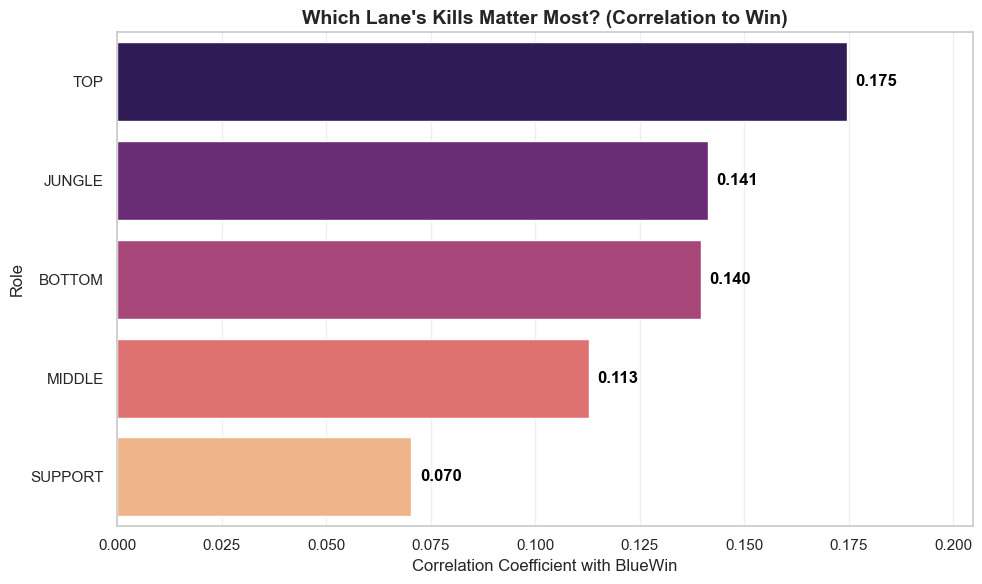

In [51]:
subset = df_standard[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'kills_P{i}' for i in range(1,6)]].copy()
melted = pd.wide_to_long(subset.reset_index(), stubnames=['Lane_P', 'kills_P'], i='MatchFk', j='PlayerNum')

lane_kills = melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['kills_P'].mean().reset_index()
pivoted = lane_kills.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='kills_P').reset_index()

lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
correlations = pivoted[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

for i, v in enumerate(correlations.values):
    ax.text(v + 0.002, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

plt.title("Which Lane's Kills Matter Most? (Correlation to Win)", fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.xlim(0, max(correlations.values) + 0.03)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟนี้เปรียบเทียบค่าความสัมพันธ์ (Correlation) ระหว่าง จำนวนการคิลแยกตามตำแหน่ง ในช่วง 10 นาทีแรก กับ ผลลัพธ์แพ้ชนะของเกม

แผนภูมินี้แสดงความสัมพันธ์ระหว่างการคิลของแต่ละตำแหน่ง ณ นาทีที่ 10 กับผลการแข่งขัน โดยเลนบนมีความสัมพันธ์กับการชนะสูงที่สุด ซึ่งบ่งชี้ว่าการคิลในช่วงต้นเกมของเลนบนส่งผลกระทบต่อรูปเกมเป็นอย่างมาก การคิลจากตำแหน่งป่าและเลนล่างก็มีความสัมพันธ์เชิงบวกที่มีนัยสำคัญเช่นกัน ในขณะที่เลนกลางจะรองลงมาเล็กน้อย

ส่วนซัพพอร์ตมีความสัมพันธ์ต่ำที่สุด ซึ่งเป็นไปตามคาดเนื่องจากอิทธิพลของซัพพอร์ตมักไม่ได้วัดจากจำนวนการคิลเป็นหลัก โดยรวมแล้ว กราฟนี้ชี้ให้เห็นว่าการคิลในช่วงต้นเกมนั้นสำคัญ แต่จะมีมูลค่าสูงสุดเมื่อตกไปอยู่ในตำแหน่งที่สามารถเปลี่ยนทรัพยากรนั้นให้กลายเป็นทอง, แรงกดดันในเลน และการคุมแผนที่ (Map control) ได้อย่างมีประสิทธิภาพ

### 2.3 Lane Kills — Direct Matchup Difference (Blue vs Red)

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\3540214032.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


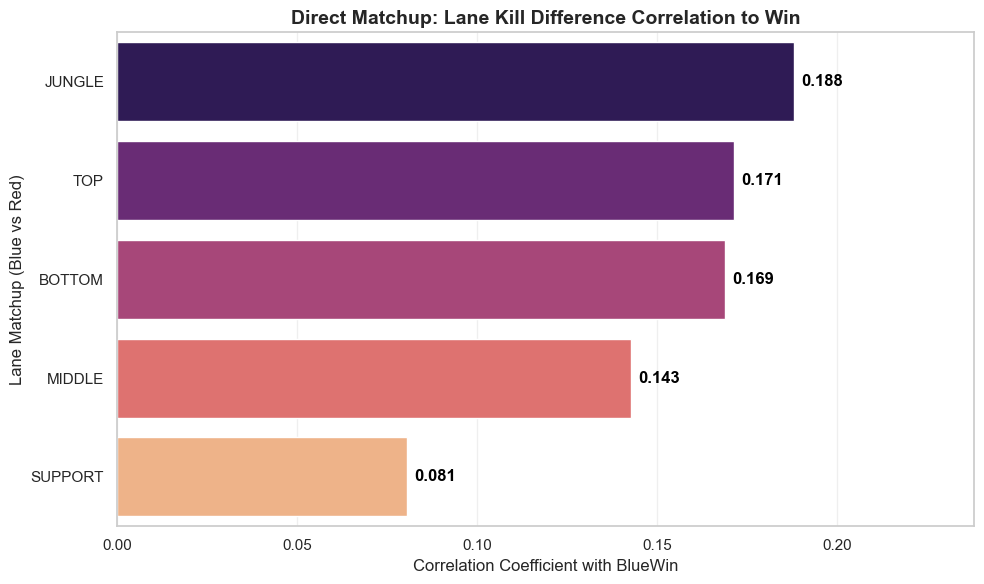

In [52]:
blue_subset = df_standard[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'kills_P{i}' for i in range(1,6)]].copy()
blue_melted = pd.wide_to_long(blue_subset.reset_index(), stubnames=['Lane_P', 'kills_P'], i='MatchFk', j='PlayerNum')
blue_lanes = blue_melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['kills_P'].mean().reset_index()
blue_lanes.rename(columns={'kills_P': 'BlueKills'}, inplace=True)

red_subset = df_standard[['MatchFk'] + [f'Lane_P{i}' for i in range(6,11)] + [f'kills_P{i}' for i in range(6,11)]].copy()
rename_dict = {f'Lane_P{i}': f'Lane_P{i-5}' for i in range(6, 11)}
rename_dict.update({f'kills_P{i}': f'kills_P{i-5}' for i in range(6, 11)})
red_subset = red_subset.rename(columns=rename_dict)

red_melted = pd.wide_to_long(red_subset.reset_index(), stubnames=['Lane_P', 'kills_P'], i='MatchFk', j='PlayerNum')
red_lanes = red_melted.groupby(['MatchFk', 'Lane_P'])['kills_P'].mean().reset_index()
red_lanes.rename(columns={'kills_P': 'RedKills'}, inplace=True)

matchups = pd.merge(blue_lanes, red_lanes, on=['MatchFk', 'Lane_P'], how='inner')
matchups['Lane_Kill_Diff'] = matchups['BlueKills'] - matchups['RedKills']

diff_pivot = matchups.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='Lane_Kill_Diff').reset_index()
lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
correlations = diff_pivot[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

for i, v in enumerate(correlations.values):
    ax.text(v + 0.002, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

plt.title('Direct Matchup: Lane Kill Difference Correlation to Win', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Lane Matchup (Blue vs Red)', fontsize=12)
plt.xlim(0, max(correlations.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นถึงค่าความสัมพันธ์ (Correlation) ระหว่าง ส่วนต่างการคิลเมื่อเทียบกับคู่แข่งโดยตรงในเลน (Direct Lane Kill Difference) ในช่วง 10 นาทีแรก กับผลลัพธ์แพ้ชนะของเกม

จะเห็นได้ว่าตำแหน่ง Top lane มีความสัมพันธ์เชื่อมโยงกับชัยชนะสูงที่สุด ตามมาด้วยตำแหน่ง Jungle ครับ สำหรับตำแหน่ง Bottom และ Middle ก็แสดงผลความสัมพันธ์เชิงบวกเช่นเดียวกัน ซึ่งหมายความว่าการชิงความได้เปรียบเรื่องการคิลได้ตั้งแต่ต้นเกมในตำแหน่งเหล่านี้ จะช่วยเพิ่มโอกาสในการพาทีมชนะให้สูงขึ้นได้ ในขณะที่ตำแหน่ง Support มีค่าความสัมพันธ์ที่อ่อนที่สุด ซึ่งเป็นผลลัพธ์ที่เป็นไปตามคาดครับ เพราะโดยปกติแล้วซัพพอร์ตไม่ใช่ตำแหน่งที่รับหน้าที่ทำดาเมจหลักหรือเน้นการฟาร์ม

กราฟนี้ช่วยบ่งบอกว่า การสร้างความได้เปรียบด้วยการคิลคู่แข่งแบบตัวต่อตัวนั้นมีความสำคัญในทุกๆ ตำแหน่ง

### 2.4 KDA — Team Efficiency (Box Plot)
KDA (Kills + Assists หารด้วย Deaths) คือตัวชี้วัดการต่อสู้ที่ครอบคลุมกว่า — ให้รางวัลกับทีมที่ต่อสู้อย่างมีประสิทธิภาพ และลงโทษทีมที่ตายโดยไม่จำเป็น

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1678895993.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


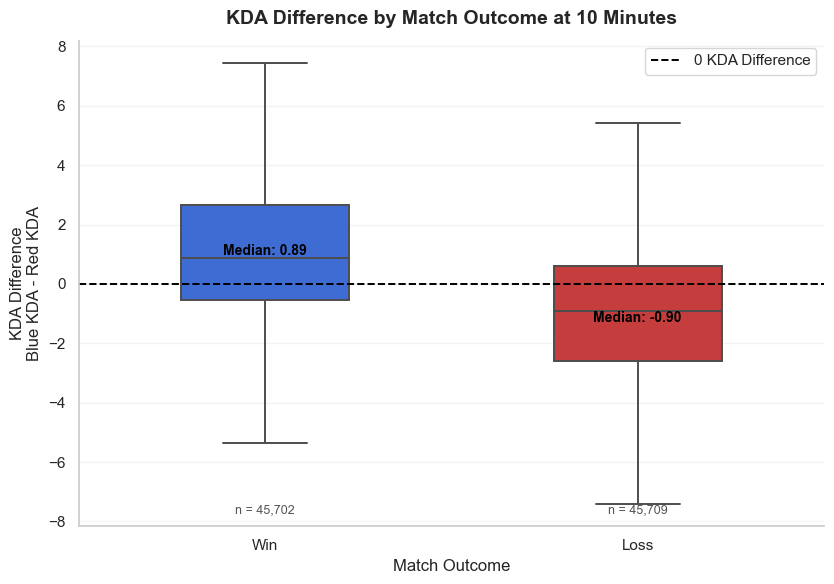

In [38]:
df_standard["KDA_Diff"] = df_standard["Blue_KDA"] - df_standard["Red_KDA"]
df_standard["Outcome"] = df_standard["BlueWin"].map({1: "Win", 0: "Loss"})
plot_df = df_standard[["Outcome", "KDA_Diff"]].dropna().copy()
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8.5, 6))
palette = {
    "Win": "#2563eb",
    "Loss": "#dc2626"
}
sns.boxplot(
    data=plot_df,
    x="Outcome",
    y="KDA_Diff",
    order=["Win", "Loss"],
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=1.4,
    ax=ax
)
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="0 KDA Difference"
)
medians = plot_df.groupby("Outcome")["KDA_Diff"].median()
for i, outcome in enumerate(["Win", "Loss"]):
    median_value = medians[outcome]
    ax.text(
        i,
        median_value,
        f"Median: {median_value:,.2f}",
        ha="center",
        va="bottom" if median_value >= 0 else "top",
        fontsize=10,
        fontweight="bold",
        color="black"
    )
counts = plot_df["Outcome"].value_counts()
y_min, y_max = ax.get_ylim()
for i, outcome in enumerate(["Win", "Loss"]):
    ax.text(
        i,
        y_min + (y_max - y_min) * 0.02,
        f"n = {counts[outcome]:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555555"
    )
ax.set_title(
    "KDA Difference by Match Outcome at 10 Minutes",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Match Outcome", fontsize=12)
ax.set_ylabel("KDA Difference\nBlue KDA - Red KDA", fontsize=12)
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

กราฟ Box plot นี้เปรียบเทียบ 'ส่วนต่างของค่า KDA (KDA Difference)' ในช่วง 10 นาทีแรก ระหว่างทีมที่ชนะและทีมที่แพ้

จะเห็นได้ว่าทีมที่ชนะมีแนวโน้มที่จะมีส่วนต่าง KDA ที่สูงกว่าเล็กน้อย ในขณะที่ทีมที่แพ้มักจะมีส่วนต่าง KDA ที่ต่ำกว่า สิ่งนี้สะท้อนให้เห็นว่า ประสิทธิภาพในการปะทะช่วงต้นเกม (Early combat performance) มีความเกี่ยวข้องกับผลแพ้ชนะของเกม

แต่อย่างไรก็ตาม การกระจายตัวของข้อมูลที่ซ้อนทับกันระหว่างกลุ่มทั้งสอง แสดงให้เห็นว่าการใช้ส่วนต่าง KDA เพียงอย่างเดียว ยังไม่ใช่ตัวทำนาย (Predictor) ชัยชนะที่สามารถเชื่อถือได้อย่างเด็ดขาด



### 2.5 Lane KDA — Direct Matchup Difference by Role

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\490576574.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations_kda.values, y=correlations_kda.index, palette='magma')


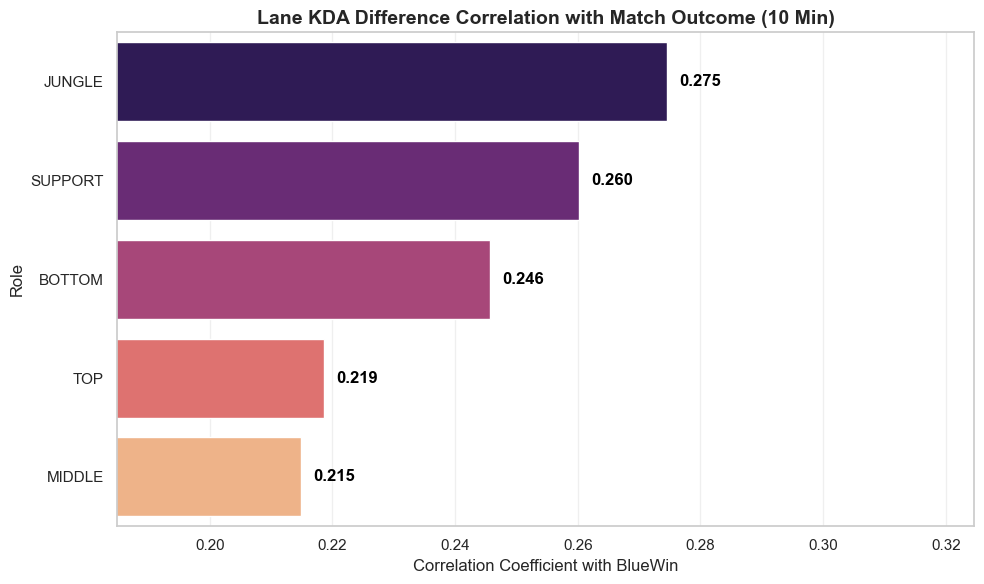

In [53]:
for i in range(1, 11):
    df_standard[f'KDA_P{i}'] = (df_standard[f'kills_P{i}'] + df_standard[f'assists_P{i}']) / (df_standard[f'deaths_P{i}'].replace(0, 1))

blue_kda = df_standard[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'KDA_P{i}' for i in range(1,6)]].copy()
blue_melted = pd.wide_to_long(blue_kda.reset_index(), stubnames=['Lane_P', 'KDA_P'], i='MatchFk', j='PlayerNum')
blue_lanes = blue_melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['KDA_P'].mean().reset_index()
blue_lanes.rename(columns={'KDA_P': 'BlueKDA'}, inplace=True)

red_kda = df_standard[['MatchFk'] + [f'Lane_P{i}' for i in range(6,11)] + [f'KDA_P{i}' for i in range(6,11)]].copy()
rename_dict = {f'Lane_P{i}': f'Lane_P{i-5}' for i in range(6, 11)}
rename_dict.update({f'KDA_P{i}': f'KDA_P{i-5}' for i in range(6, 11)})
red_kda = red_kda.rename(columns=rename_dict)

red_melted = pd.wide_to_long(red_kda.reset_index(), stubnames=['Lane_P', 'KDA_P'], i='MatchFk', j='PlayerNum')
red_lanes = red_melted.groupby(['MatchFk', 'Lane_P'])['KDA_P'].mean().reset_index()
red_lanes.rename(columns={'KDA_P': 'RedKDA'}, inplace=True)

matchups = pd.merge(blue_lanes, red_lanes, on=['MatchFk', 'Lane_P'], how='inner')
matchups['Lane_KDA_Diff'] = matchups['BlueKDA'] - matchups['RedKDA']

diff_pivot = matchups.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='Lane_KDA_Diff').reset_index()
lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
diff_pivot = diff_pivot.dropna(subset=lanes_to_keep)
correlations_kda = diff_pivot[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations_kda.values, y=correlations_kda.index, palette='magma')

for i, v in enumerate(correlations_kda.values):
    offset = 0.002 if v >= 0 else -0.002
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f"{v:.3f}", color='black', va='center', fontweight='bold', ha=ha)

plt.title('Lane KDA Difference Correlation with Match Outcome (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.xlim(min(correlations_kda.values) - 0.03, max(correlations_kda.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นถึงค่าความสัมพันธ์ (Correlation) ระหว่าง ส่วนต่างของค่า KDA เมื่อเทียบกับคู่แข่งในเลน (Lane KDA Difference) ในช่วง 10 นาทีแรก กับผลลัพธ์แพ้ชนะของเกม

จะเห็นได้ว่าตำแหน่ง Jungle มีความสัมพันธ์กับการชนะเกมสูงที่สุด ตามมาด้วยตำแหน่ง Support และ Bottom lane สิ่งนี้ชี้ให้เห็นว่า ความได้เปรียบด้าน KDA ในช่วงต้นเกมนั้นมีความสำคัญเป็นพิเศษสำหรับตำแหน่งที่มีอิทธิพลต่อการกดดันแผนที่ (Map pressure) และจังหวะทีมไฟต์ (Team fights)

จุดที่น่าสนใจคือตำแหน่ง Support กระโดดขึ้นมามีค่าความสัมพันธ์ที่สูงมากในกราฟนี้ นั่นเป็นเพราะสำหรับผู้เล่นซัพพอร์ตแล้ว การมีส่วนร่วมช่วยเหลือทีม (Assists) และการตายน้อย (Low deaths) ถือเป็นตัวชี้วัดประสิทธิภาพ (Performance) ที่มีความหมายมากกว่าการดูแค่ตัวเลขการฟาร์ม (CS) หรือการคิลเพียงอย่างเดียว

## Section 3: Map Objectives

นอกเหนือจากผลงานของผู้เล่นรายบุคคล ทีมต้องแข่งขันกันเพื่อควบคุม Objective สำคัญบนแผนที่ ที่เวลา 10 นาที มี Objective หลัก 3 ประเภทที่สามารถ Secure ได้ ได้แก่ Dragon, Rift Herald และ Tower

### 3.1 Dragon — First Dragon Impact on Win Rate

In [16]:
df_standard['BlueDragonKills'].value_counts()

BlueDragonKills
0    56632
1    34729
2       50
Name: count, dtype: int64

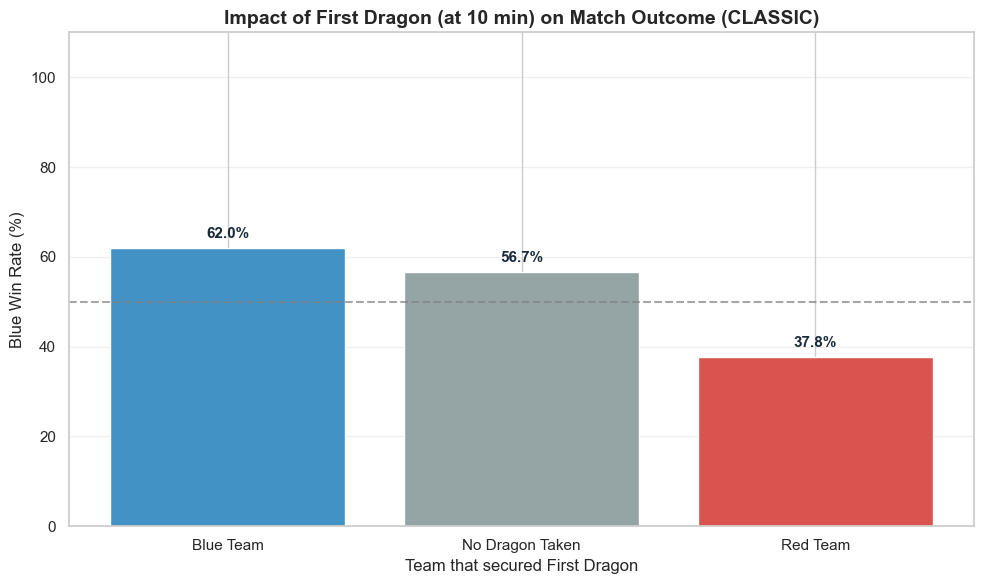

In [17]:
colors = ['#4292C6', '#95A5A6', '#D9534F']
conditions = [
    (df_standard['BlueDragonKills'] > df_standard['RedDragonKills']),
    (df_standard['RedDragonKills'] > df_standard['BlueDragonKills'])
]
choices = ['Blue Team', 'Red Team']
df_standard['SecuredBy'] = np.select(conditions, choices, default='No Dragon Taken')
win_rates = df_standard.groupby('SecuredBy')['BlueWin'].mean() * 100
order = ['Blue Team', 'No Dragon Taken', 'Red Team']
win_rates = win_rates.reindex(order).fillna(0)
plt.figure(figsize=(10, 6))
bars = plt.bar(order, win_rates, color=colors, width=0.8)
plt.title('Impact of First Dragon (at 10 min) on Match Outcome (CLASSIC)', fontsize=14, fontweight='bold')
plt.xlabel('Team that secured First Dragon', fontsize=12)
plt.ylabel('Blue Win Rate (%)', fontsize=12)
plt.ylim(0, 110)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%',
                 ha='center', va='bottom', fontweight='bold', color='#1A2A3A', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นถึงอิทธิพลของการเก็บมังกรตัวแรก (First Dragon Control) ในช่วง 10 นาทีแรก ที่มีต่อผลลัพธ์แพ้ชนะของเกม

จะสังเกตเห็นว่า เมื่อทีมฝั่ง Blue สามารถเก็บมังกรตัวแรกได้ โอกาสชนะ (Win Rate) จะพุ่งสูงขึ้นไปถึง 62% ซึ่งทะลุเส้นมาตรฐานที่ 50% ขึ้นไปอย่างเห็นได้ชัดครับ และในกรณีที่ยังไม่มีทีมไหนจัดการมังกรได้เลย โอกาสชนะจะอยู่ที่ระดับเกือบๆ 50% พอดี ซึ่งสะท้อนว่ารูปเกมยังคงมีความสมดุล (Balanced) อยู่

แต่ในทางกลับกัน หากทีมฝั่ง Red เป็นฝ่ายชิงมังกรตัวแรกไปได้ โอกาสชนะของทีมฝั่ง Blue จะร่วงตกลงมาเหลือเพียง 37.8% เท่านั้นครับ

โดยสรุป: ข้อมูลชุดนี้ชี้ให้เห็นอย่างชัดเจนว่า การคุมมังกรได้ตั้งแต่ต้นเกม ถือเป็นการชิงความได้เปรียบด้าน Objective ที่มีนัยสำคัญมาก

### 3.2 Voidgrubs — Voidgrubs Impact on Win Rate

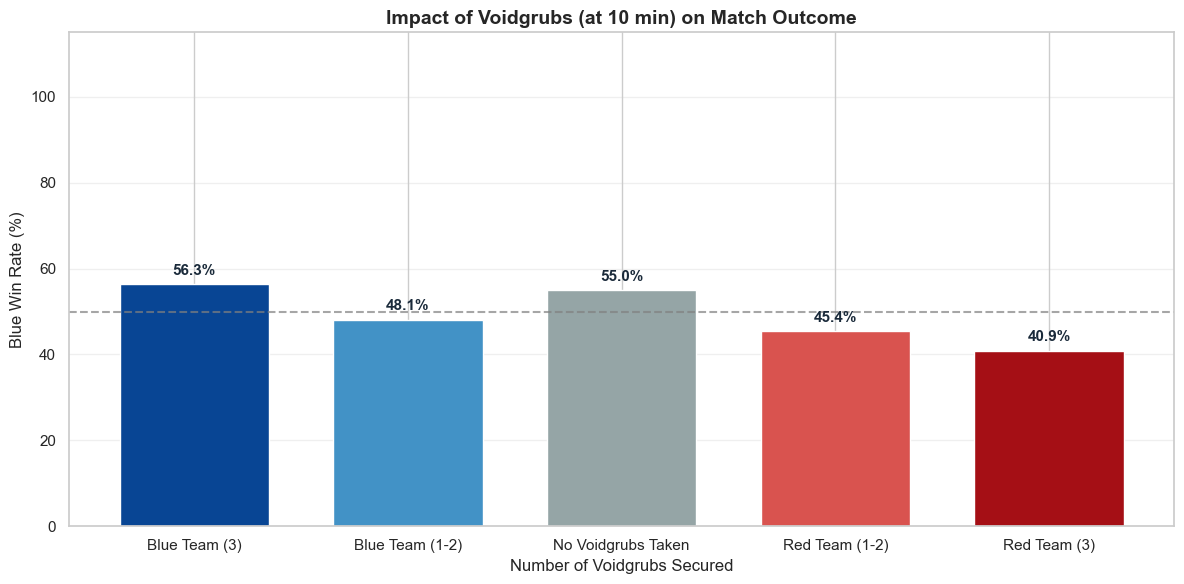

In [18]:
colors = ['#084594', '#4292C6', '#95A5A6', '#D9534F', '#A50F15']
conditions = [
    (df_standard['BlueRiftHeraldKills'] == 3),
    (df_standard['BlueRiftHeraldKills'] >= 1) & (df_standard['BlueRiftHeraldKills'] < 3),
    (df_standard['RedRiftHeraldKills'] >= 1) & (df_standard['RedRiftHeraldKills'] < 3),
    (df_standard['RedRiftHeraldKills'] == 3)
]
choices = ['Blue Team (3)', 'Blue Team (1-2)', 'Red Team (1-2)', 'Red Team (3)']
df_standard['VoidgrubControl'] = np.select(conditions, choices, default='No Voidgrubs Taken')
win_rates = df_standard.groupby('VoidgrubControl')['BlueWin'].mean() * 100
order = ['Blue Team (3)', 'Blue Team (1-2)', 'No Voidgrubs Taken', 'Red Team (1-2)', 'Red Team (3)']
win_rates = win_rates.reindex(order).fillna(0)
plt.figure(figsize=(12, 6))
bars = plt.bar(order, win_rates, color=colors, width=0.7)
plt.title('Impact of Voidgrubs (at 10 min) on Match Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Number of Voidgrubs Secured', fontsize=12)
plt.ylabel('Blue Win Rate (%)', fontsize=12)
plt.ylim(0, 115)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%',
                 ha='center', va='bottom', fontweight='bold', color='#1A2A3A', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นถึงอิทธิพลของการควบคุม Voidgrubs (หนอนวอยด์) ในช่วง 10 นาทีแรกที่มีต่อผลลัพธ์ของเกม

เมื่อทีมฝั่ง Blue สามารถเก็บ Voidgrubs ได้ครบทั้ง 3 ตัว โอกาสชนะ (Win Rate) จะเพิ่มขึ้นเป็น 56.3% ซึ่งบ่งบอกว่าการควบคุม Voidgrubs ได้อย่างเบ็ดเสร็จ (Full Control) ช่วยสร้างความได้เปรียบในช่วงต้นเกมได้อย่างมีนัยสำคัญ

อย่างไรก็ตาม การเก็บได้เพียง 1-2 ตัว กลับไม่ได้ส่งผลเชิงบวกที่แข็งแกร่งนัก โดยโอกาสชนะของฝั่ง Blue ยังคงทรงตัวอยู่ในระดับใกล้เคียงกับค่ามาตรฐาน (Neutral) ส่วนในทางกลับกัน เมื่อทีมฝั่ง Red เป็นฝ่ายชิง Voidgrubs ไปได้ โอกาสชนะของทีม Blue จะลดต่ำลง โดยเฉพาะอย่างยิ่งเมื่อฝั่ง Red สามารถเก็บไปได้ครบทั้ง 3 ตัว

โดยสรุป: กราฟนี้ชี้ให้เห็นว่า Voidgrubs จะส่งผลต่อเกมมากที่สุดก็ต่อเมื่อมีทีมใดทีมหนึ่งสามารถเก็บได้ครบทั้งชุด (Full set) ในขณะที่การควบคุมได้เพียงบางส่วนจะมีอิทธิพลต่อผลแพ้ชนะน้อยกว่าอย่างเห็นได้ชัด

### 3.3 Tower — Tower Impact on Win Rate

In [19]:
df_standard['RedTowerKills'].value_counts()

RedTowerKills
0    86013
1     3453
2     1278
3      489
4      126
5       33
6       11
7        6
8        2
Name: count, dtype: int64

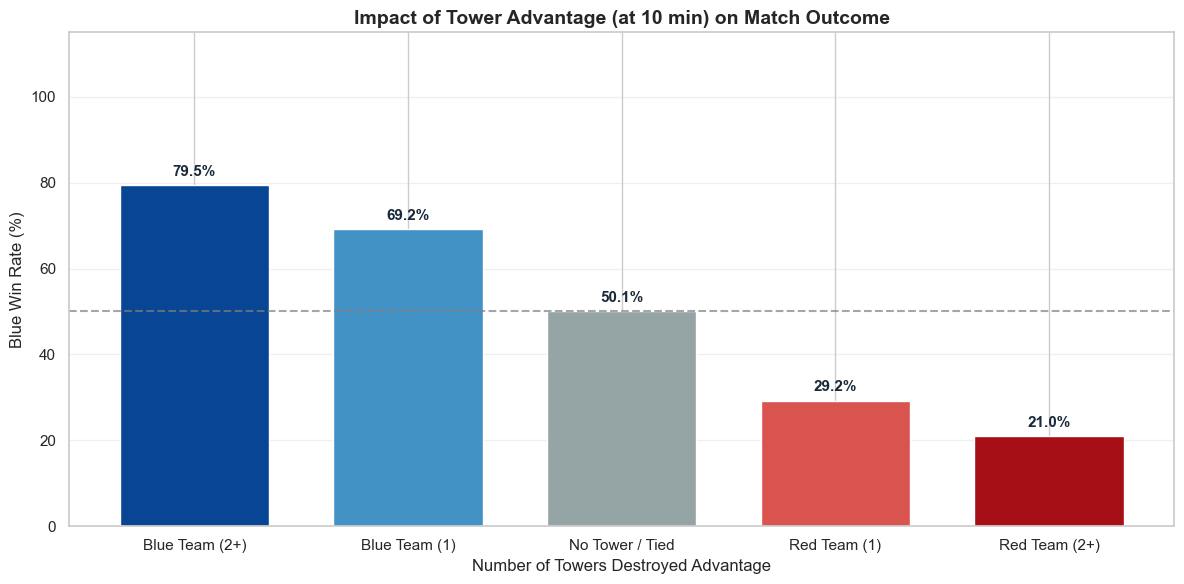

In [20]:
colors = ['#084594', '#4292C6', '#95A5A6', '#D9534F', '#A50F15']
conditions = [
    (df_standard['BlueTowerKills'] >= 2) & (df_standard['BlueTowerKills'] > df_standard['RedTowerKills']),
    (df_standard['BlueTowerKills'] == 1) & (df_standard['BlueTowerKills'] > df_standard['RedTowerKills']),
    (df_standard['RedTowerKills'] == 1) & (df_standard['RedTowerKills'] > df_standard['BlueTowerKills']),
    (df_standard['RedTowerKills'] >= 2) & (df_standard['RedTowerKills'] > df_standard['BlueTowerKills'])
]
choices = ['Blue Team (2+)', 'Blue Team (1)', 'Red Team (1)', 'Red Team (2+)']
df_standard['TowerAdvantage'] = np.select(conditions, choices, default='No Tower / Tied')
win_rates = df_standard.groupby('TowerAdvantage')['BlueWin'].mean() * 100
order = ['Blue Team (2+)', 'Blue Team (1)', 'No Tower / Tied', 'Red Team (1)', 'Red Team (2+)']
win_rates = win_rates.reindex(order).fillna(0)
plt.figure(figsize=(12, 6))
bars = plt.bar(order, win_rates, color=colors, width=0.7)
plt.title('Impact of Tower Advantage (at 10 min) on Match Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Number of Towers Destroyed Advantage', fontsize=12)
plt.ylabel('Blue Win Rate (%)', fontsize=12)
plt.ylim(0, 115)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%',
                 ha='center', va='bottom', fontweight='bold', color='#1A2A3A', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นว่า 'ความได้เปรียบด้านจำนวนป้อม (Tower Advantage)' ในช่วง 10 นาทีแรก

เมื่อทีมสีน้ำเงินมีความได้เปรียบเรื่องป้อมอัตราการชนะของพวกเขาจะเพิ่มขึ้นอย่างมหาศาล หากทีมสีน้ำเงินนำอยู่ 1 ป้อม อัตราการชนะจะอยู่ที่ 69.2% และหากนำห่างตั้งแต่ 2 ป้อมขึ้นไป อัตราการชนะจะพุ่งสูงถึง 79.5%

ในกรณีที่ไม่มีฝ่ายใดได้เปรียบเรื่องป้อม หรือจำนวนป้อมเท่ากัน อัตราการชนะของทีมสีน้ำเงินจะอยู่ที่ 50.1% ซึ่งถือว่าเป็นค่ากลาง (Neutral) อย่างพอดิบพอดีแต่เมื่อทีมสีแดงเป็นฝ่ายได้เปรียบเรื่องป้อม อัตราการชนะของทีมสีน้ำเงินจะดิ่งลงอย่างรวดเร็ว หากทีมสีแดงนำอยู่ 1 ป้อม อัตราการชนะของทีมสีน้ำเงินจะเหลือเพียง 29.2% และหากทีมสีแดงนำ 2 ป้อมขึ้นไป อัตราการชนะจะลดต่ำลงไปอีกเหลือเพียง 21.0%

### 3.4 Objective Correlation Summary

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1152454995.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


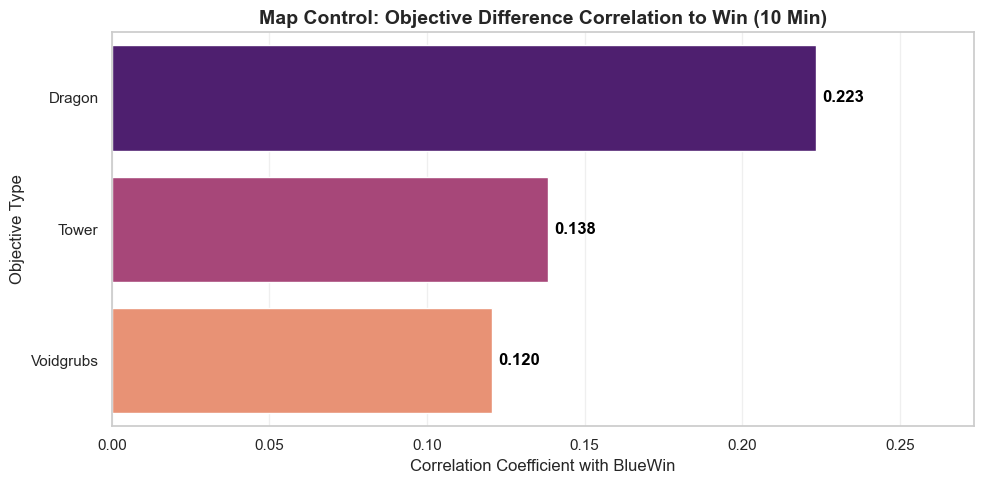

In [54]:
df_standard['Dragon_Diff'] = df_standard['BlueDragonKills'] - df_standard['RedDragonKills']
df_standard['Voidgrub_Diff'] = df_standard['BlueRiftHeraldKills'] - df_standard['RedRiftHeraldKills']
df_standard['Tower_Diff'] = df_standard['BlueTowerKills'] - df_standard['RedTowerKills']
obj_cols = ['Dragon_Diff', 'Voidgrub_Diff', 'Tower_Diff']
correlations = df_standard[obj_cols + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)
rename_objs = {
    'Dragon_Diff': 'Dragon',
    'Voidgrub_Diff': 'Voidgrubs',
    'Tower_Diff': 'Tower'
}
correlations.index = correlations.index.map(rename_objs)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')
for i, v in enumerate(correlations.values):
    ax.text(v + 0.002, i, f"{v:.3f}", color='black', va='center', fontweight='bold')
plt.title('Map Control: Objective Difference Correlation to Win (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Objective Type', fontsize=12)
plt.xlim(0, max(correlations.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟนี้เปรียบเทียบค่าความสัมพันธ์ (Correlation) ระหว่าง 'ส่วนต่างของการเก็บ Objective (Objective Differences)' ในช่วง 10 นาทีแรก กับผลลัพธ์แพ้ชนะของเกม

จะเห็นได้ว่า มังกร (Dragon) มีความสัมพันธ์เชิงบวกกับโอกาสชนะสูงที่สุด (0.223) สิ่งนี้สะท้อนให้เห็นว่าในชุดข้อมูลนี้ การควบคุมมังกรได้ตั้งแต่ต้นเกม ถือเป็นตัวชี้วัด (Indicator) ด้าน Objective บนแผนที่ที่สำคัญที่สุด

สำหรับ Rift Herald แม้จะแสดงทิศทางความสัมพันธ์เชิงบวกกับการชนะเช่นเดียวกัน แต่ก็มีน้ำหนักที่อ่อนกว่า โดยอยู่ที่ 0.138 

จุดที่น่าสังเกตคือ ป้อม (Tower) กลับมีค่าความสัมพันธ์ต่ำที่สุด (0.12) ซึ่งในมุมมองของการวิเคราะห์ข้อมูล สาเหตุหลักน่าจะเป็นเพราะโดยธรรมชาติของเกม ป้อมมักจะยังไม่ค่อยถูกพังลงในช่วงก่อน 10 นาทีแรก

## Section 4: Damage

ความเสียหายที่ดีลออกไปคือตัววัดโดยตรงของการมีส่วนร่วมในการต่อสู้ของผู้เล่นแต่ละคน เราจะวิเคราะห์ทั้งความเสียหายที่ดีลใส่ Champion และความเสียหายที่ดีลใส่ Turret

### 4.1 Team Damage — Box Plot

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\2318346.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


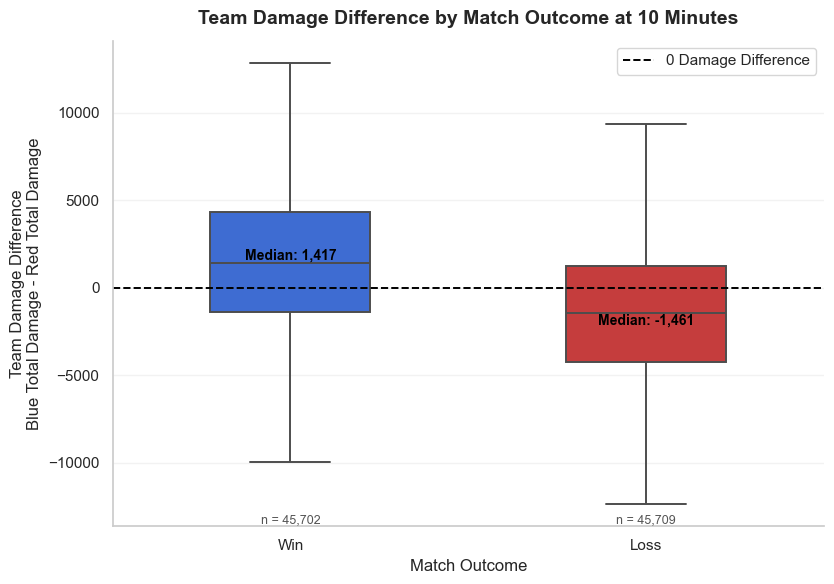

In [39]:
blue_dmg_cols = [f"DmgDealt_P{i}" for i in range(1, 6)]
red_dmg_cols = [f"DmgDealt_P{i}" for i in range(6, 11)]
df_standard["Blue_Total_Dmg"] = df_standard[blue_dmg_cols].sum(axis=1)
df_standard["Red_Total_Dmg"] = df_standard[red_dmg_cols].sum(axis=1)
df_standard["Team_Dmg_Diff"] = df_standard["Blue_Total_Dmg"] - df_standard["Red_Total_Dmg"]
df_standard["Outcome"] = df_standard["BlueWin"].map({1: "Win", 0: "Loss"})
plot_df = df_standard[["Outcome", "Team_Dmg_Diff"]].dropna().copy()
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8.5, 6))
palette = {
    "Win": "#2563eb",
    "Loss": "#dc2626"
}
sns.boxplot(
    data=plot_df,
    x="Outcome",
    y="Team_Dmg_Diff",
    order=["Win", "Loss"],
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=1.4,
    ax=ax
)
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="0 Damage Difference"
)
medians = plot_df.groupby("Outcome")["Team_Dmg_Diff"].median()
for i, outcome in enumerate(["Win", "Loss"]):
    median_value = medians[outcome]
    ax.text(
        i,
        median_value,
        f"Median: {median_value:,.0f}",
        ha="center",
        va="bottom" if median_value >= 0 else "top",
        fontsize=10,
        fontweight="bold",
        color="black"
    )
counts = plot_df["Outcome"].value_counts()
for i, outcome in enumerate(["Win", "Loss"]):
    ax.text(
        i,
        ax.get_ylim()[0],
        f"n = {counts[outcome]:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555555"
    )
ax.set_title(
    "Team Damage Difference by Match Outcome at 10 Minutes",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Match Outcome")
ax.set_ylabel("Team Damage Difference\nBlue Total Damage - Red Total Damage")
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

กราฟ Box plot นี้เปรียบเทียบ ส่วนต่างของดาเมจระดับทีม (Team Damage Difference) ในช่วง 10 นาทีแรก ระหว่างทีมที่ชนะและทีมที่แพ้

โดยทั่วไป ทีมที่ชนะมักจะมีส่วนต่างดาเมจที่สูงกว่า ในขณะที่ทีมที่แพ้จะมีแนวโน้มของส่วนต่างดาเมจที่ต่ำกว่า สิ่งนี้ชี้ให้เห็นว่า การชิงความได้เปรียบด้านการทำดาเมจตั้งแต่ช่วงต้นเกม (Early damage advantage) มีความสัมพันธ์กับโอกาสในการชนะที่สูงขึ้น

โดยภาพรวม ส่วนต่างดาเมจของทีม ถือเป็นตัวชี้วัดประสิทธิภาพการต่อสู้ช่วงต้นเกม (Early-game combat indicator) ที่มีประโยชน์มากครับ แต่มันก็ควรถูกนำไปพิจารณาวิเคราะห์ร่วมกับปัจจัยอื่นๆ อย่างรอบด้าน ไม่ว่าจะเป็น การเงิน (Gold), จำนวนคิล (Kills), การฟาร์ม (CS), การแย่งชิง Objective

### 4.2 Lane Damage — Raw Correlation by Role

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1521216374.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations_dmg.values, y=correlations_dmg.index, palette='magma')


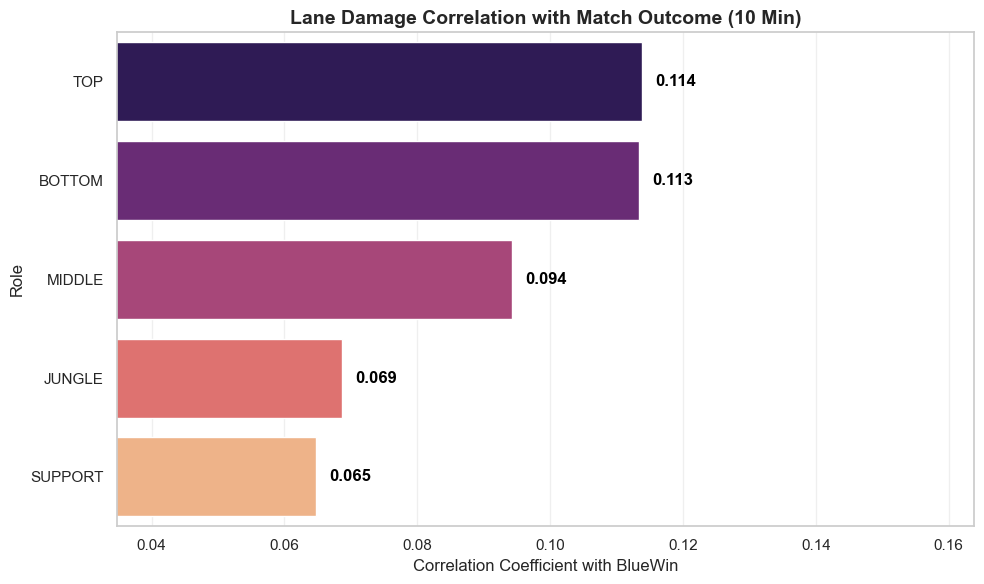

In [55]:
subset_dmg = df_standard[['MatchFk', 'BlueWin'] +
                          [f'Lane_P{i}' for i in range(1, 6)] +
                          [f'DmgDealt_P{i}' for i in range(1, 6)]].copy()

melted_dmg = pd.wide_to_long(
    subset_dmg.reset_index(),
    stubnames=['Lane_P', 'DmgDealt_P'],
    i='MatchFk',
    j='PlayerNum'
)

lane_dmg = melted_dmg.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['DmgDealt_P'].mean().reset_index()
pivoted_dmg = lane_dmg.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='DmgDealt_P').reset_index()

lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
pivoted_dmg = pivoted_dmg.dropna(subset=lanes_to_keep)

correlations_dmg = pivoted_dmg[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations_dmg.values, y=correlations_dmg.index, palette='magma')

for i, v in enumerate(correlations_dmg.values):
    offset = 0.002 if v >= 0 else -0.002
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f"{v:.3f}", color='black', va='center', fontweight='bold', ha=ha)

plt.title('Lane Damage Correlation with Match Outcome (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.xlim(min(correlations_dmg.values) - 0.03, max(correlations_dmg.values) + 0.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นถึงค่าความสัมพันธ์ (Correlation) ระหว่าง 'ปริมาณการทำดาเมจของแต่ละตำแหน่ง' ในช่วง 10 นาทีแรก กับผลแพ้ชนะของเกม

โดยภาพรวม ทุกตำแหน่งมีความสัมพันธ์เชิงบวก ซึ่งหมายความว่ายิ่งทำดาเมจได้เยอะ ก็ยิ่งมีแนวโน้มที่จะชนะเกมมากขึ้น

### 4.3 Lane Damage — Direct Matchup Difference (Blue vs Red)

C:\Users\lchan\AppData\Local\Temp\ipykernel_12020\1493961514.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


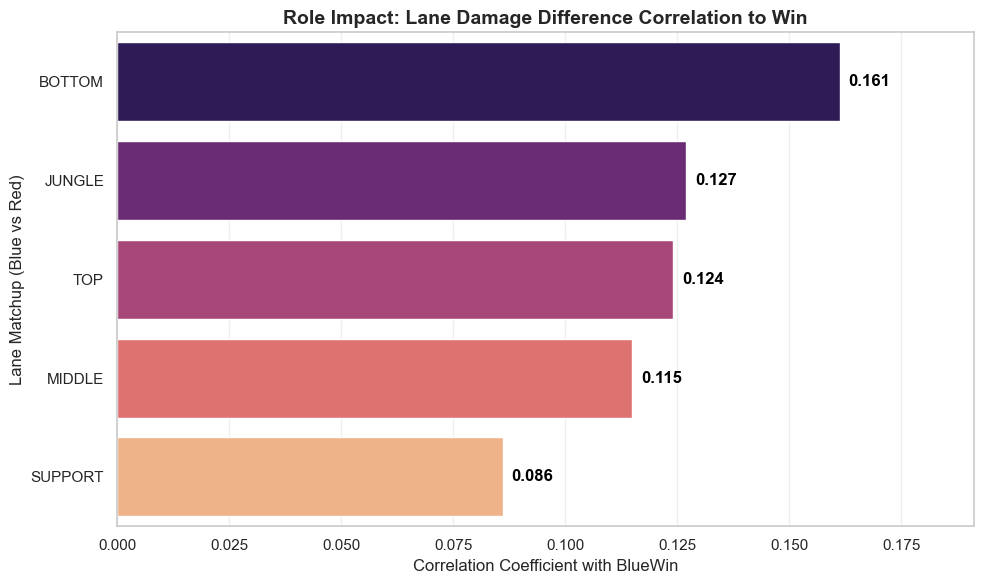

In [56]:
blue_subset = df_standard[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'DmgDealt_P{i}' for i in range(1,6)]].copy()
blue_melted = pd.wide_to_long(blue_subset.reset_index(), stubnames=['Lane_P', 'DmgDealt_P'], i='MatchFk', j='PlayerNum')
blue_lanes = blue_melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])['DmgDealt_P'].mean().reset_index()
blue_lanes.rename(columns={'DmgDealt_P': 'BlueDmg'}, inplace=True)

red_subset = df_standard[['MatchFk'] + [f'Lane_P{i}' for i in range(6,11)] + [f'DmgDealt_P{i}' for i in range(6,11)]].copy()
rename_dict = {f'Lane_P{i}': f'Lane_P{i-5}' for i in range(6, 11)}
rename_dict.update({f'DmgDealt_P{i}': f'DmgDealt_P{i-5}' for i in range(6, 11)})
red_subset = red_subset.rename(columns=rename_dict)

red_melted = pd.wide_to_long(red_subset.reset_index(), stubnames=['Lane_P', 'DmgDealt_P'], i='MatchFk', j='PlayerNum')
red_lanes = red_melted.groupby(['MatchFk', 'Lane_P'])['DmgDealt_P'].mean().reset_index()
red_lanes.rename(columns={'DmgDealt_P': 'RedDmg'}, inplace=True)

matchups = pd.merge(blue_lanes, red_lanes, on=['MatchFk', 'Lane_P'], how='inner')
matchups['Lane_Dmg_Diff'] = matchups['BlueDmg'] - matchups['RedDmg']

diff_pivot = matchups.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='Lane_Dmg_Diff').reset_index()
lanes_to_keep = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
correlations = diff_pivot[lanes_to_keep + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

for i, v in enumerate(correlations.values):
    offset = 0.002 if v > 0 else -0.015
    ax.text(v + offset, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

plt.title('Role Impact: Lane Damage Difference Correlation to Win', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Lane Matchup (Blue vs Red)', fontsize=12)
plt.xlim(min(0, min(correlations.values) - 0.02), max(0, max(correlations.values) + 0.03))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นถึงค่าความสัมพันธ์ (Correlation) ระหว่าง 'ส่วนต่างของการทำดาเมจเมื่อเทียบกับคู่แข่งโดยตรงในเลน (Direct Lane Damage Difference)' ในช่วง 10 นาทีแรก กับผลลัพธ์แพ้ชนะของเกม

จะเห็นได้ว่าตำแหน่ง Bottom lane มีความสัมพันธ์กับชัยชนะสูงที่สุด ตามมาด้วยตำแหน่ง Top lane สิ่งนี้ชี้ให้เห็นว่า ความได้เปรียบด้านดาเมจตั้งแต่ต้นเกมที่มาจากตำแหน่ง ตัวแบกของทีม(Carry) หรือตำแหน่งที่เน้นการดวลแบบ 1v1 เพื่อกดเลน (Lane-dominant roles) มีความเชื่อมโยงกับการพาทีมไปสู่ชัยชนะ

สำหรับตำแหน่ง Jungle และ Middle ก็แสดงความสัมพันธ์เชิงบวกเช่นเดียวกัน ซึ่งหมายความว่าการกดดาเมจเหนือคู่แข่งในตำแหน่งเหล่านี้ก็ยังคงสำคัญครับ เพียงแต่จะมีน้ำหนักน้อยกว่าเล็กน้อย ในขณะที่ตำแหน่ง Support มีค่าความสัมพันธ์ที่อ่อนที่สุด ซึ่งผลลัพธ์นี้เป็นไปตามที่เราคาดการณ์ไว้ครับ เพราะอิมแพคต่อเกมของผู้เล่นซัพพอร์ต ไม่ได้ถูกชี้วัดจากการทำดาเมจเป็นหลักอยู่แล้ว



## Section 5: Summary & Conclusion

หลังจากวิเคราะห์ครบทั้ง 4 มิติ ได้แก่ เศรษฐกิจ, การต่อสู้, Objective บนแผนที่ และความเสียหาย เราจะสรุปผลการค้นพบทั้งหมดในมุมมองเดียวเพื่อตอบคำถามหลัก

### 5.1 Master Summary — What Matters Most at 10 Minutes?

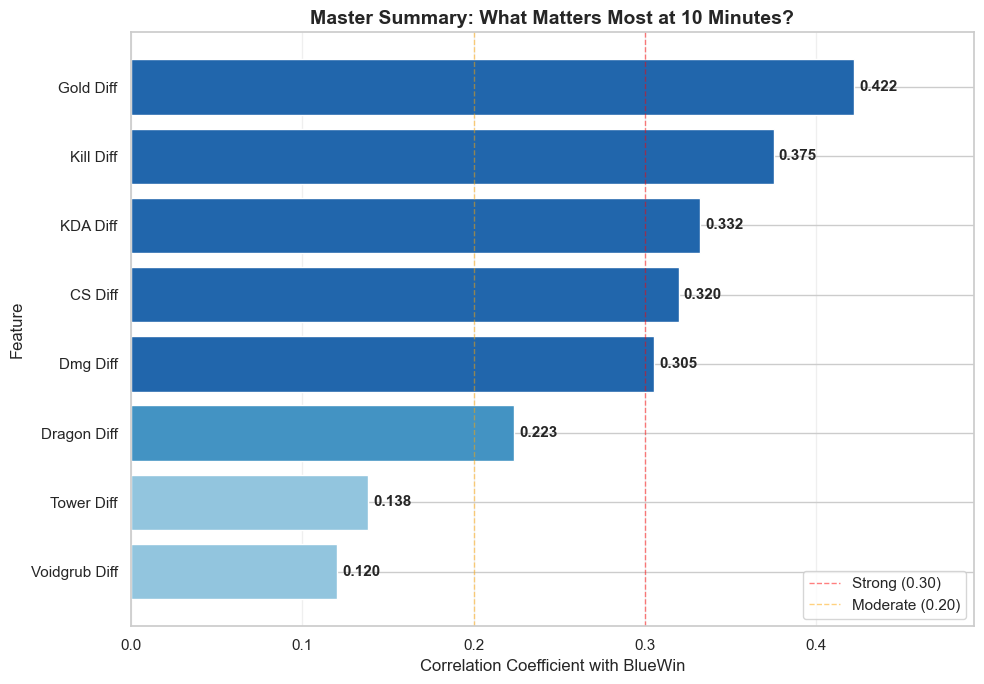

In [25]:
summary_cols = {
    'Gold Diff':    'Diff_TotalGold',
    'Tower Diff':   'Diff_TowerKills',
    'KDA Diff':     'Diff_KDA',
    'Kill Diff':    'Diff_kills',
    'Dragon Diff':  'Diff_DragonKills',
    'Dmg Diff':     'Diff_DmgDealt',
    'CS Diff':      'Diff_MinionsKilled',
    'Voidgrub Diff':  'Voidgrub_Diff',
}

master_corr = {
    label: df_standard[col].corr(df_standard['BlueWin'])
    for label, col in summary_cols.items()
}

master_series = pd.Series(master_corr).sort_values(ascending=True)
colors_master = ['#2166ac' if v >= 0.3 else '#4393c3' if v >= 0.2 else '#92c5de' for v in master_series.values]

plt.figure(figsize=(10, 7))
ax = plt.barh(master_series.index, master_series.values, color=colors_master)

for i, v in enumerate(master_series.values):
    plt.text(v + 0.003, i, f"{v:.3f}", va='center', fontweight='bold', fontsize=11)

plt.title('Master Summary: What Matters Most at 10 Minutes?', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xlim(0, max(master_series.values) + 0.07)
plt.axvline(0.3, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Strong (0.30)')
plt.axvline(0.2, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (0.20)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**การอ่านกราฟ (Master Summary):**

ส่วนต่างการเงิน (Gold Difference) มีอิทธิพลต่อเกมมากที่สุดในช่วง 10 นาทีแรก โดยมีค่าความสัมพันธ์ (Correlation) กับการชนะเกมสูงที่สุดถึง 0.431 ซึ่งหมายความว่า ทีมที่สามารถทำเงินทิ้งห่างได้ตั้งแต่ช่วงต้นเกม จะมีโอกาสคว้าชัยชนะที่สูงกว่ามาก ๆ

ถัดจากเรื่องเงิน ตัวชี้วัด (Indicators) ที่มีความแข็งแกร่งรองลงมาก็คือ ส่วนต่างการคิล (Kill Difference), ส่วนต่าง KDA, ส่วนต่างดาเมจ (Damage Difference) และส่วนต่างการฟาร์ม (CS Difference) ตามลำดับครับ ซึ่งฟีเจอร์กลุ่มนี้ล้วนมีค่าความสัมพันธ์สูงกว่า 0.30

ในทางกลับกัน ตัวชี้วัดกลุ่ม ส่วนต่างด้าน Objective กลับมีน้ำหนักที่อ่อนกว่าในกราฟนี้ครับ โดยมี มังกร (Dragon Difference) เป็นฟีเจอร์ด้าน Objective ที่สำคัญที่สุด ด้วยค่าความสัมพันธ์ 0.214 ซึ่งจัดอยู่ในระดับปานกลาง (Moderate indicator) ในขณะที่ส่วนต่างของ Voidgrub และ Tower นั้น ถือว่ามีอิทธิพลในการทำนายผลที่เบาบางกว่ามากเมื่อวัดผลที่นาทีที่ 10


### 5.2 Lane Summary — Gold vs CS vs Kill Difference by Role

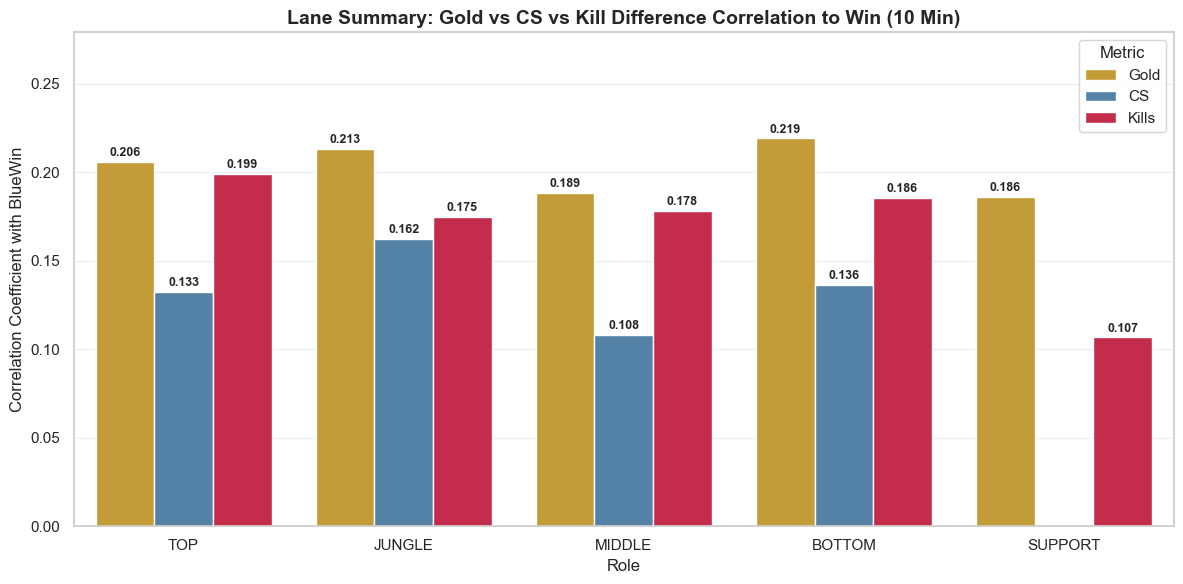

In [26]:
def get_lane_diff_corr(df, blue_cols_prefix, red_cols_prefix, value_name):
    blue = df[['MatchFk', 'BlueWin'] + [f'Lane_P{i}' for i in range(1,6)] + [f'{blue_cols_prefix}_P{i}' for i in range(1,6)]].copy()
    blue_melted = pd.wide_to_long(blue.reset_index(), stubnames=['Lane_P', f'{blue_cols_prefix}_P'], i='MatchFk', j='PlayerNum')
    blue_lanes = blue_melted.groupby(['MatchFk', 'Lane_P', 'BlueWin'])[f'{blue_cols_prefix}_P'].mean().reset_index()
    blue_lanes.rename(columns={f'{blue_cols_prefix}_P': 'BlueVal'}, inplace=True)

    red = df[['MatchFk'] + [f'Lane_P{i}' for i in range(6,11)] + [f'{red_cols_prefix}_P{i}' for i in range(6,11)]].copy()
    rename_dict = {f'Lane_P{i}': f'Lane_P{i-5}' for i in range(6, 11)}
    rename_dict.update({f'{red_cols_prefix}_P{i}': f'{red_cols_prefix}_P{i-5}' for i in range(6, 11)})
    red = red.rename(columns=rename_dict)

    red_melted = pd.wide_to_long(red.reset_index(), stubnames=['Lane_P', f'{red_cols_prefix}_P'], i='MatchFk', j='PlayerNum')
    red_lanes = red_melted.groupby(['MatchFk', 'Lane_P'])[f'{red_cols_prefix}_P'].mean().reset_index()
    red_lanes.rename(columns={f'{red_cols_prefix}_P': 'RedVal'}, inplace=True)

    matchups = pd.merge(blue_lanes, red_lanes, on=['MatchFk', 'Lane_P'])
    matchups['Diff'] = matchups['BlueVal'] - matchups['RedVal']

    pivot = matchups.pivot(index=['MatchFk', 'BlueWin'], columns='Lane_P', values='Diff').reset_index()
    lanes = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
    pivot = pivot.dropna(subset=lanes)

    corr = pivot[lanes + ['BlueWin']].corr()['BlueWin'].drop('BlueWin').sort_values(ascending=False)
    return pd.DataFrame({'Lane': corr.index, 'Correlation': corr.values, 'Metric': value_name})

gold_corr = get_lane_diff_corr(df_standard, 'TotalGold', 'TotalGold', 'Gold')
cs_corr   = get_lane_diff_corr(df_standard, 'MinionsKilled', 'MinionsKilled', 'CS')
kill_corr  = get_lane_diff_corr(df_standard, 'kills', 'kills', 'Kills')

combined = pd.concat([gold_corr, cs_corr, kill_corr], ignore_index=True)
lane_order = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=combined,
    x='Lane',
    y='Correlation',
    hue='Metric',
    order=lane_order,
    palette={'Gold': 'goldenrod', 'CS': 'steelblue', 'Kills': 'crimson'}
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, fontweight='bold', padding=2)

plt.title('Lane Summary: Gold vs CS vs Kill Difference Correlation to Win (10 Min)', fontsize=14, fontweight='bold')
plt.xlabel('Role', fontsize=12)
plt.ylabel('Correlation Coefficient with BlueWin', fontsize=12)
plt.legend(title='Metric')
plt.ylim(0, max(combined['Correlation']) + 0.06)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**การอ่านกราฟ (Lane Summary):**

กราฟนี้เปรียบเทียบ Gold, CS, และ Kill ทั้ง 3 ตัวชี้วัดในแต่ละเลนพร้อมกัน ผลที่ได้:

- **Gold (สีทอง) มีค่า Correlation สูงสุดในทุกเลน**  ยืนยันว่าทองคือราชาของตัวชี้วัด
- **Kill (สีแดง) มาเป็นอันดับสอง**  การต่อสู้ชนะมีผลแต่รองจากทอง
- **CS (สีฟ้า) มีค่าต่ำสุด**  CS เป็นรากฐานของทอง แต่ตัวมันเองมีผลน้อยกว่า
- **เลน Top และ Jungle** มีค่าสูงสุดในทุกเมตริก ยืนยันว่า Solo Lane และ Jungle คือตำแหน่งสำคัญที่สุดในการกำหนดชัยชนะ